# Pareto Front Analysis of Terminal Cell Lineage

## Comparative Summary: C. elegans vs C. briggsae

**Key question:** For terminal cells, does the real lineage sit on the Pareto frontier
trading off physical proximity vs. expression similarity? How does this vary across:

1. **Data modalities** — C. elegans protein vs RNA-seq vs C. briggsae RNA-seq
2. **Lineage subtrees** — Full tree vs AB, ABa, ABp, P1 branches
3. **Cell types** — Neurons, muscle, epithelium, etc.

All Pareto fronts are shown with costs expressed as **ratios of the real lineage cost**,
so the lineage reference point is always at **(1, 1)**. Values < 1 mean the optimal
assignment beats the real lineage on that axis. Edge retention ratios (fraction of
real parent→child edges preserved) are directly comparable across all conditions.

In [1]:
%load_ext autoreload
%autoreload 2
import pandas as pd, numpy as np, json
from tqdm import tqdm
from scipy.optimize import linear_sum_assignment
from scipy.spatial.distance import cosine
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
import seaborn as sns
from collections import defaultdict
from joblib import Parallel, delayed
import matplotlib as mpl
mpl.rcParams['figure.dpi'] = 150
sns.set_style("whitegrid")


In [2]:
# ── Shared helper functions ──

def map_names(did):
    if did == "P4a": return "Z3"
    elif did == "P4p": return "Z2"
    elif did == "P0a": return "AB"
    else: return did

def load_json(path):
    with open(path) as f: return json.load(f)

def lineage_edge_ratio(ri, ci, tp):
    return sum(1 for i,j in zip(ri,ci) if tp[i]==tp[j]) / len(tp)

def pareto_sweep(xyz_mat, exp_mat, terminal_parents, iteration=1000):
    """Run Pareto sweep and return key scale-invariant metrics."""
    xyz_n = (xyz_mat - xyz_mat.min()) / (xyz_mat.max() - xyz_mat.min())
    exp_n = (exp_mat - exp_mat.min()) / (exp_mat.max() - exp_mat.min())
    lx, le = xyz_n.diagonal().sum(), exp_n.diagonal().sum()

    best_er, best_dist, best_alpha = 0.0, np.inf, 0.0
    edge_ratios = []

    for i in range(iteration + 1):
        alpha = i / iteration
        ri, ci = linear_sum_assignment(alpha * xyz_n + (1 - alpha) * exp_n)
        er = lineage_edge_ratio(ri, ci, terminal_parents)
        edge_ratios.append(er)
        cx, ce = xyz_n[ri,ci].sum(), exp_n[ri,ci].sum()
        d = np.sqrt((cx-lx)**2 + (ce-le)**2)
        if er > best_er: best_er = er
        if d < best_dist: best_dist, best_alpha = d, alpha

    # Edge ratios at the two extremes
    ri_e, ci_e = linear_sum_assignment(exp_n)
    er_expr = lineage_edge_ratio(ri_e, ci_e, terminal_parents)
    ri_s, ci_s = linear_sum_assignment(xyz_n)
    er_spatial = lineage_edge_ratio(ri_s, ci_s, terminal_parents)

    return dict(expr_opt_er=er_expr, spatial_opt_er=er_spatial, max_er=best_er,
                closest_dist=best_dist, edge_ratios=np.array(edge_ratios))

def compute_ratio_pareto(xyz_mat, exp_mat, terminal_parents, iteration=1000):
    """Pareto front with costs as ratios of lineage cost — (1,1) reference."""
    lx, le = xyz_mat.diagonal().sum(), exp_mat.diagonal().sum()
    xr, er_ = xyz_mat/lx, exp_mat/le
    xl, el, edges = [], [], []
    for i in range(iteration + 1):
        a = i/iteration
        ri, ci = linear_sum_assignment(a*xr + (1-a)*er_)
        xl.append(xr[ri,ci].sum()); el.append(er_[ri,ci].sum())
        edges.append(lineage_edge_ratio(ri, ci, terminal_parents))
    edges = np.array(edges)
    kp = {'expr_opt_idx': 0, 'spatial_opt_idx': iteration, 'max_er_idx': int(np.argmax(edges))}
    return np.array(xl), np.array(el), edges, kp

def build_cost_matrices(terminal_nodes, terminal_parents, xyz_map, exp_df, sel_features=None):
    """Build L2 spatial and cosine expression cost matrices."""
    sel = exp_df[sel_features] if sel_features is not None else exp_df
    n = len(terminal_parents)
    xm, em = np.zeros((n,n)), np.zeros((n,n))
    fdict = {}
    for i, p in enumerate(terminal_parents):
        for j, c in enumerate(terminal_nodes):
            xm[i,j] = np.linalg.norm(xyz_map[p] - xyz_map[c])
            em[i,j] = cosine(sel.loc[p].values, sel.loc[c].values)
    for node in terminal_nodes: fdict[node] = exp_df.loc[node].values
    for parent in terminal_parents: fdict[parent] = exp_df.loc[parent].values
    return xm, em, fdict

print("Helpers loaded.")


Helpers loaded.


### Alternative Cost Normalization: Std-Based Scaling

The ratio-to-lineage normalization forces the lineage to (1,1), which may introduce bias
when interpreting the lineage's position relative to the Pareto front. An alternative is
to scale each cost axis by the **standard deviation** of total costs obtained by
**randomly swapping edges within first-cousin groups** (terminal cells sharing the same
grandparent). This expresses costs in units of 'natural variation' within lineage branches,
providing a biologically meaningful reference frame independent of the lineage itself.

In [3]:
# ── Grandparent mapping & first-cousin group construction ──

def build_grandparent_map(root):
    """Map each cell name to its grandparent (parent's parent).
    First cousins share the same grandparent but have different parents."""
    gp_map = {}
    def dfs(node, parent_name=None, grandparent_name=None):
        name = map_names(node.get("did", ""))
        gp_map[name] = grandparent_name
        for child in node.get("children", []):
            dfs(child, name, parent_name)
    dfs(root)
    return gp_map


def build_cousin_groups(terminal_nodes, gp_mapping):
    """Group terminal cell indices by grandparent. Only groups >=2 members."""
    groups = {}
    for idx, node in enumerate(terminal_nodes):
        gp = gp_mapping.get(node)
        if gp is not None:
            groups.setdefault(gp, []).append(idx)
    cousin_groups = [indices for gp, indices in groups.items() if len(indices) >= 2]
    cousin_groups.sort(key=len, reverse=True)
    return cousin_groups

print("Grandparent & cousin group functions defined.")


Grandparent & cousin group functions defined.


In [4]:
# ── Std-based cost normalization via cousin-group randomization ──

def compute_cousin_random_stats(xyz_mat, exp_mat, cousin_groups, n_random=1000, seed=42):
    """Compute mean/std of total costs under first-cousin-group permutation."""
    rng = np.random.default_rng(seed)
    n_cells = xyz_mat.shape[0]
    random_xyz, random_exp = [], []
    for _ in range(n_random):
        perm = list(range(n_cells))
        for group in cousin_groups:
            if len(group) < 2:
                continue
            shuffled = group.copy()
            rng.shuffle(shuffled)
            for orig_idx, new_idx in zip(group, shuffled):
                perm[orig_idx] = new_idx
        total_xyz = sum(xyz_mat[i, perm[i]] for i in range(n_cells))
        total_exp = sum(exp_mat[i, perm[i]] for i in range(n_cells))
        random_xyz.append(total_xyz)
        random_exp.append(total_exp)
    random_xyz = np.array(random_xyz)
    random_exp = np.array(random_exp)
    return {
        'xyz_mean': float(random_xyz.mean()), 'xyz_std': float(random_xyz.std()),
        'exp_mean': float(random_exp.mean()), 'exp_std': float(random_exp.std()),
        'random_xyz': random_xyz, 'random_exp': random_exp,
    }


def compute_std_scaled_pareto(xyz_mat, exp_mat, terminal_parents, random_stats, iteration=1000):
    """Pareto front with costs scaled by randomization std (not lineage diagonal).
    Edge retention key metrics are identical to ratio-to-lineage method."""
    xs = xyz_mat / random_stats['xyz_std']
    es = exp_mat / random_stats['exp_std']
    xl, el, edge_list = [], [], []
    for i in range(iteration + 1):
        a = i / iteration
        ri, ci = linear_sum_assignment(a * xs + (1 - a) * es)
        xl.append(xs[ri, ci].sum())
        el.append(es[ri, ci].sum())
        edge_list.append(lineage_edge_ratio(ri, ci, terminal_parents))
    edge_list = np.array(edge_list)
    kp = {'expr_opt_idx': 0, 'spatial_opt_idx': iteration, 'xyz_opt_idx': iteration, 'max_er_idx': int(np.argmax(edge_list))}
    return np.array(xl), np.array(el), edge_list, kp

print("Std-based normalization functions defined.")


Std-based normalization functions defined.


In [5]:
# ── Load shared data ──
lineage_data = load_json('./data/cell_lineage.json')
apoptotic_cells = pd.read_csv('data/apoptotic_cells.txt', sep='\t', header=None)[0].tolist()

# ── C. elegans tracking (two cutoffs) ──
# T_CE=255: used for subtree & cell type analyses (C. elegans only)
# T_CE_EARLY=230: used for cross-species comparison (comparable to briggsae T=155)
T_CE = 255
T_CE_EARLY = 230

def load_elegans_tracking(tcut):
    ts_ce = pd.read_csv("./data/embryo1/tracks.txt", sep="\t")
    ts_ce = ts_ce[ts_ce["t"] <= tcut]
    xyz_map = {}
    valid = []
    for name in ts_ce["name"].unique():
        tp = ts_ce[ts_ce['name'] == name]["t"].values
        if len(tp) == 1 and tp[0] == tcut: continue
        xyz_map[name] = ts_ce[ts_ce['name'] == name].values[-1][1:4] * 0.1625
        valid.append(name)
    return xyz_map, valid

xyz_ce, valid_ce = load_elegans_tracking(T_CE)
xyz_ce_early, valid_ce_early = load_elegans_tracking(T_CE_EARLY)
print(f"C. elegans tracked: T<={T_CE} -> {len(valid_ce)} cells, T<={T_CE_EARLY} -> {len(valid_ce_early)} cells")

# ── C. briggsae tracking ──
T_CB = 155
ts_cb = pd.read_csv("data/c_briggsae/CD140715HLH1cbp1.csv")
ts_cb = ts_cb[ts_cb["time"] <= T_CB]
xyz_cb = {}
valid_cb = []
for name in ts_cb["cell"].unique():
    tp = ts_cb[ts_cb['cell'] == name]["time"].values
    if len(tp) == 1 and tp[0] == T_CB: continue
    xyz_cb[name] = ts_cb[ts_cb['cell'] == name].values[-1][8:11]
    valid_cb.append(name)
print(f"C. briggsae tracked: {len(valid_cb)} cells")

# ── Expression data ──
protein_exp = pd.read_csv("./data/protein/aggregated_all/s3_zscore.csv", index_col=0).T
prot_sel = pd.read_csv('expression_embedding/results/elegans_protein_linear_baseline/top20_protein_names.csv')['protein'].tolist()

ce_rna = pd.read_csv("data/c_briggsae/science.adu8249/c_elegans_tf.csv", index_col=0).T
cb_rna = pd.read_csv("data/c_briggsae/science.adu8249/c_briggsae_tf.csv", index_col=0).T
rna_sel = pd.read_csv('expression_embedding/results/cross_species_rna_linear/rna_selected_features.tsv', names=['tf'], sep='\t')['tf'].tolist()

# Valid cell intersections
# Full-cutoff valid sets (T=255): for subtree & cell type
v_prot = [n for n in valid_ce if n in protein_exp.index]
v_ce_rna = [n for n in valid_ce if n in ce_rna.index]
# Early-cutoff valid sets (T=230): for cross-species comparison
v_prot_early = [n for n in valid_ce_early if n in protein_exp.index]
v_ce_rna_early = [n for n in valid_ce_early if n in ce_rna.index]
# C. briggsae (old file, T=155)
v_cb_rna = [n for n in valid_cb if n in cb_rna.index]
print(f"Valid: protein(T=255)={len(v_prot)}, protein(T=230)={len(v_prot_early)}, ceRNA(T=255)={len(v_ce_rna)}, ceRNA(T=230)={len(v_ce_rna_early)}, cbRNA={len(v_cb_rna)}")


C. elegans tracked: T<=255 -> 1006 cells, T<=230 -> 752 cells


C. briggsae tracked: 750 cells
Valid: protein(T=255)=1004, protein(T=230)=750, ceRNA(T=255)=853, ceRNA(T=230)=683, cbRNA=677


In [6]:
# ── Compute grandparent map (shared across all C. elegans analyses) ──
gp_map = build_grandparent_map(lineage_data)
print(f"Grandparent map: {len(gp_map)} cells mapped")


Grandparent map: 2183 cells mapped


In [7]:
# ── Find subtree root & collect terminal cells ──
def find_node(root, target):
    t = map_names(target)
    def search(n):
        if map_names(n.get("did","")) == t: return n
        for c in n.get("children",[]):
            r = search(c)
            if r is not None: return r
        return None
    return search(root)

def collect_terminals(root, valid_names, subtree=None):
    start = find_node(root, subtree) if subtree else root
    tn, tp = [], []
    def dfs(node, parent, ancestors=[]):
        children = node.get("children",[])
        ln = map_names(node["did"])
        if len(children) == 0:
            pln = map_names(parent['did']) if parent else None
            if ln in valid_names and pln in valid_names:
                tn.append(ln); tp.append(pln)
        else:
            for c in children: dfs(c, node, ancestors+[ln])
    dfs(start, None)
    return tn, tp

# Compute for all three datasets
# 1) Protein
# Full-cutoff terminals (T=255): for subtree & cell type
tn_prot, tp_prot = collect_terminals(lineage_data, v_prot)
tn_er, tp_er = collect_terminals(lineage_data, v_ce_rna)
# Early-cutoff terminals (T=230): for cross-species comparison
tn_prot_early, tp_prot_early = collect_terminals(lineage_data, v_prot_early)
tn_er_early, tp_er_early = collect_terminals(lineage_data, v_ce_rna_early)
# C. briggsae (old file, T=155)
tn_cb, tp_cb = collect_terminals(lineage_data, v_cb_rna)

print(f"Protein full tree: T=255 -> {len(tn_prot)} cells, T=230 -> {len(tn_prot_early)} cells")
print(f"C. elegans RNA full tree: T=255 -> {len(tn_er)} cells, T=230 -> {len(tn_er_early)} cells")
print(f"C. briggsae RNA full tree: T=155 -> {len(tn_cb)} cells")

# Build cost matrices
# Full-cutoff (T=255): for subtree & cell type
xm_prot, em_prot, fd_prot = build_cost_matrices(tn_prot, tp_prot, xyz_ce, protein_exp, prot_sel)
xm_er, em_er, fd_er = build_cost_matrices(tn_er, tp_er, xyz_ce, ce_rna, rna_sel)
# Early-cutoff (T=230): for cross-species
xm_prot_early, em_prot_early, _ = build_cost_matrices(tn_prot_early, tp_prot_early, xyz_ce_early, protein_exp, prot_sel)
xm_er_early, em_er_early, _ = build_cost_matrices(tn_er_early, tp_er_early, xyz_ce_early, ce_rna, rna_sel)
# C. briggsae (T=155)
xm_cb, em_cb, fd_cb = build_cost_matrices(tn_cb, tp_cb, xyz_cb, cb_rna, rna_sel)
print("Cost matrices built.")


Protein full tree: T=255 -> 299 cells, T=230 -> 90 cells
C. elegans RNA full tree: T=255 -> 231 cells, T=230 -> 70 cells
C. briggsae RNA full tree: T=155 -> 69 cells


Cost matrices built.


In [8]:
# ── Compute random stats for all datasets (needed for std-based plots) ──

# Protein T=255 (full: subtree & cell type analysis)
prot_groups = build_cousin_groups(tn_prot, gp_map)
prot_rs = compute_cousin_random_stats(xm_prot, em_prot, prot_groups, n_random=500, seed=42)
print(f"Protein T=255: xyz_std={prot_rs['xyz_std']:.1f}, exp_std={prot_rs['exp_std']:.3f}")

# Protein T=230 (early: cross-species comparison)
prot_early_groups = build_cousin_groups(tn_prot_early, gp_map)
prot_early_rs = compute_cousin_random_stats(xm_prot_early, em_prot_early, prot_early_groups, n_random=500, seed=42)
print(f"Protein T=230: xyz_std={prot_early_rs['xyz_std']:.1f}, exp_std={prot_early_rs['exp_std']:.3f}")

# C. elegans RNA T=255
er_groups = build_cousin_groups(tn_er, gp_map)
er_rs = compute_cousin_random_stats(xm_er, em_er, er_groups, n_random=500, seed=42)
print(f"C.elegans RNA T=255: xyz_std={er_rs['xyz_std']:.1f}, exp_std={er_rs['exp_std']:.3f}")

# C. elegans RNA T=230 (early: cross-species)
er_early_groups = build_cousin_groups(tn_er_early, gp_map)
er_early_rs = compute_cousin_random_stats(xm_er_early, em_er_early, er_early_groups, n_random=500, seed=42)
print(f"C.elegans RNA T=230: xyz_std={er_early_rs['xyz_std']:.1f}, exp_std={er_early_rs['exp_std']:.3f}")

# C. briggsae T=155
cb_groups_rs = build_cousin_groups(tn_cb, gp_map)
cb_rs = compute_cousin_random_stats(xm_cb, em_cb, cb_groups_rs, n_random=500, seed=42)
print(f"C.briggsae T=155: xyz_std={cb_rs['xyz_std']:.1f}, exp_std={cb_rs['exp_std']:.3f}")

print("Random stats computed for all datasets.")


Protein T=255: xyz_std=30.8, exp_std=0.923
Protein T=230: xyz_std=19.0, exp_std=0.429
C.elegans RNA T=255: xyz_std=25.6, exp_std=1.902
C.elegans RNA T=230: xyz_std=19.3, exp_std=0.287
C.briggsae T=155: xyz_std=170.5, exp_std=0.242
Random stats computed for all datasets.


In [9]:
# ── Shared x_front and markers (used by all Pareto plots) ──
x_front = np.linspace(0, 1, 1001)
markers = {'expr_opt_idx': 's', 'spatial_opt_idx': 'o', 'max_er_idx': 'D'}


---
## 1. Full Tree — Cross-Dataset Comparison

Top 20 selected features for each dataset. C. elegans protein vs C. elegans RNA vs C. briggsae RNA.

In [10]:
# ── Run Pareto for all three full-tree datasets ──
# Cross-species comparison: use early cutoffs for elegans (T=230), briggsae T=155
res_prot_xs = pareto_sweep(xm_prot_early, em_prot_early, tp_prot_early)
res_er_xs   = pareto_sweep(xm_er_early,   em_er_early,   tp_er_early)
res_cb      = pareto_sweep(xm_cb,          em_cb,          tp_cb)

# ── Summary table ──
full_tree_df = pd.DataFrame({
    'Dataset': ['C. elegans\nProtein (top 20, T=230)', 'C. elegans\nRNA (top 20, T=230)', 'C. briggsae\nRNA (top 20, T=155)'],
    'N Cells': [len(tn_prot_early), len(tn_er_early), len(tn_cb)],
    'Expr Opt ER': [res_prot_xs['expr_opt_er'], res_er_xs['expr_opt_er'], res_cb['expr_opt_er']],
    'Max ER': [res_prot_xs['max_er'], res_er_xs['max_er'], res_cb['max_er']],
    'Spatial Opt ER': [res_prot_xs['spatial_opt_er'], res_er_xs['spatial_opt_er'], res_cb['spatial_opt_er']],
    'Closest Dist': [res_prot_xs['closest_dist'], res_er_xs['closest_dist'], res_cb['closest_dist']],
}).set_index('Dataset')
full_tree_df


,N Cells,Expr Opt ER,Max ER,Spatial Opt ER,Closest Dist
Dataset,,,,,
"C. elegans\nProtein (top 20, T=230)",90,0.211111,0.966667,0.844444,0.073796
"C. elegans\nRNA (top 20, T=230)",70,0.100000,0.957143,0.885714,0.070088
"C. briggsae\nRNA (top 20, T=155)",69,0.130435,0.753623,0.492754,0.244804


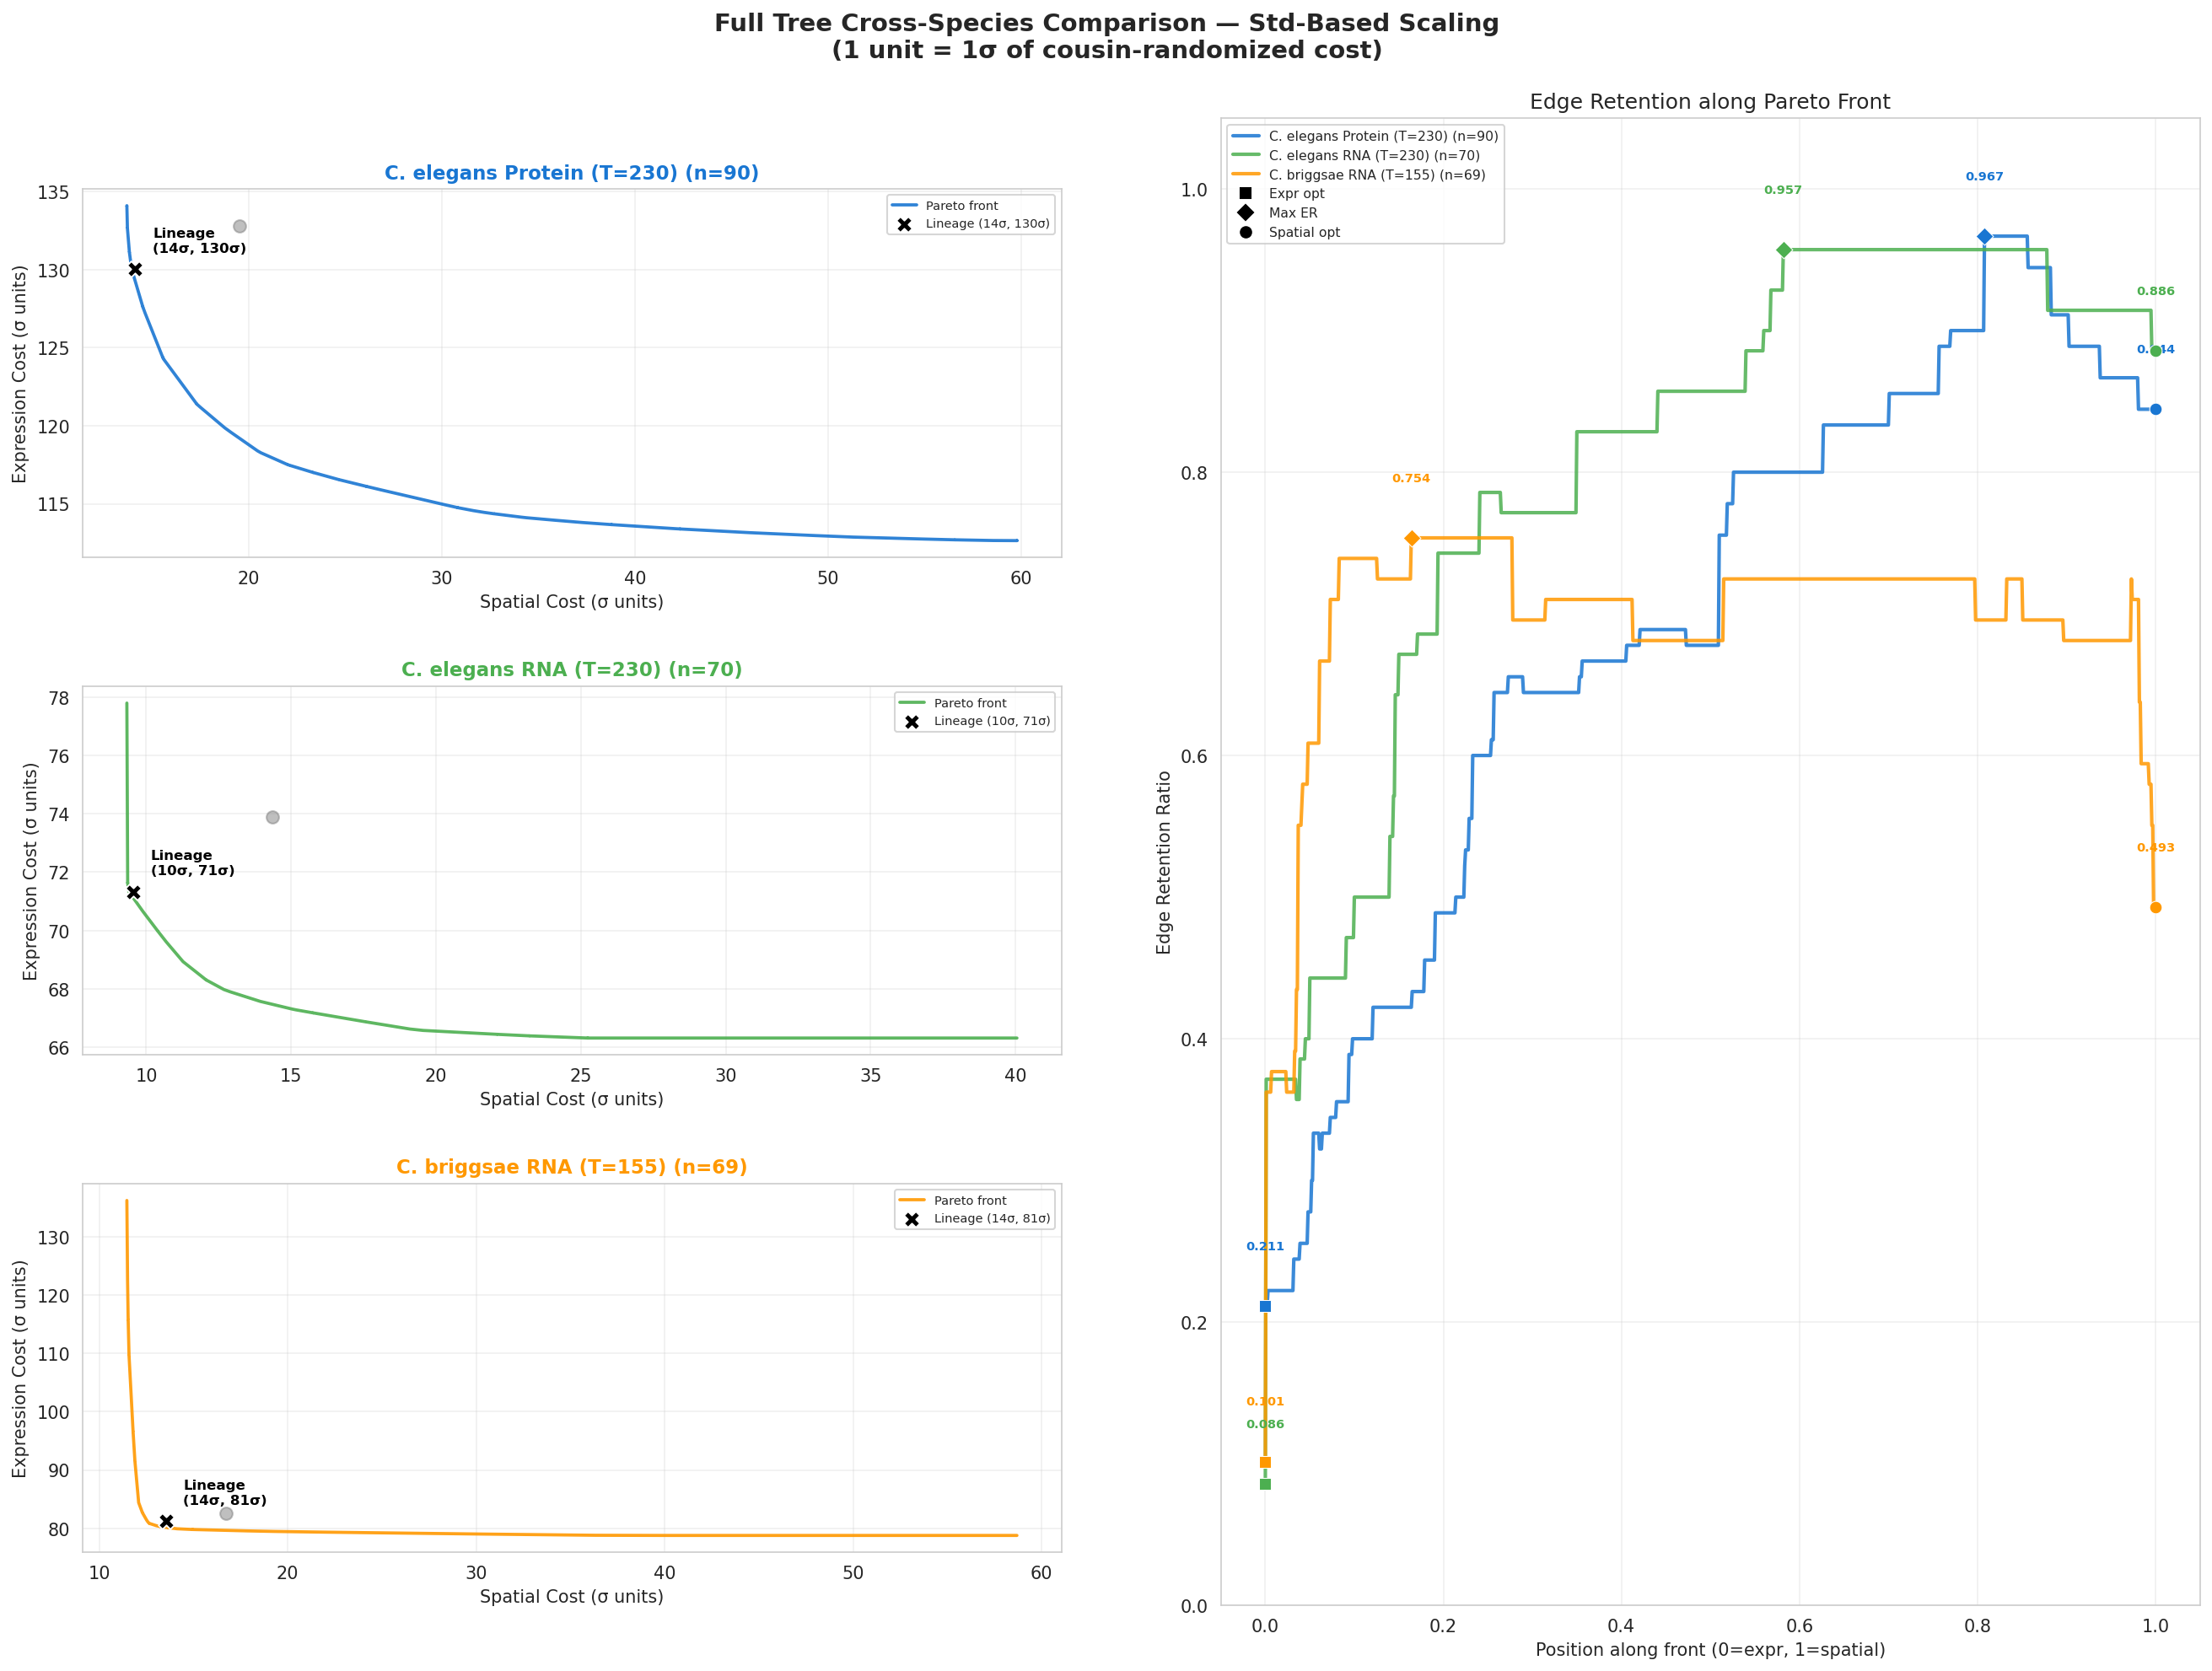

In [11]:
# ── Figure: Full tree cross-species comparison (std-based scaling) ──
# Pareto fronts stacked vertically; edge retention overlaid

datasets = [
    ('C. elegans Protein (T=230)', xm_prot_early, em_prot_early, tp_prot_early, '#1976D2', prot_early_rs),
    ('C. elegans RNA (T=230)',     xm_er_early,   em_er_early,   tp_er_early,   '#4CAF50', er_early_rs),
    ('C. briggsae RNA (T=155)',    xm_cb,         em_cb,         tp_cb,         '#FF9800', cb_rs),
]

fig = plt.figure(figsize=(22, 14))
x_front = np.linspace(0, 1, 1001)
markers = {'expr_opt_idx': 's', 'spatial_opt_idx': 'o', 'max_er_idx': 'D'}

# ── TOP: 3 stacked Pareto panels (one per dataset) ──
gs_pareto = fig.add_gridspec(3, 1, left=0.03, right=0.38, hspace=0.35)

for idx, (name, xm, em, tp, color, rs) in enumerate(datasets):
    ax = fig.add_subplot(gs_pareto[idx])
    xyz_arr, exp_arr, edge_arr, kp = compute_std_scaled_pareto(xm, em, tp, rs)
    n = len(tp)
    
    # Lineage position in std units
    lx = xm.diagonal().sum() / rs['xyz_std']
    le = em.diagonal().sum() / rs['exp_std']
    # Random mean position
    rx = rs['xyz_mean'] / rs['xyz_std']
    re = rs['exp_mean'] / rs['exp_std']
    
    ax.plot(xyz_arr, exp_arr, color=color, lw=1.8, alpha=0.9, label='Pareto front')
    ax.scatter(lx, le, color=color, marker='X', s=80, edgecolors='white', lw=0.8, zorder=6)
    ax.scatter(rx, re, color='gray', marker='o', s=50, alpha=0.5, zorder=5)
    ax.scatter(lx, le, color='black', marker='X', s=80, edgecolors='white', lw=0.8, zorder=10,
              label=f'Lineage ({lx:.0f}σ, {le:.0f}σ)')
    
    # Annotate lineage position
    ax.annotate(f'Lineage\n({lx:.0f}σ, {le:.0f}σ)', (lx, le),
                xytext=(10, 10), textcoords='offset points', fontsize=8, color='black', fontweight='bold')
    
    ax.set_xlabel('Spatial Cost (σ units)'); ax.set_ylabel('Expression Cost (σ units)')
    ax.set_title(f'{name} (n={n})', fontsize=11, color=color, fontweight='bold')
    ax.legend(fontsize=7, loc='upper right'); ax.grid(True, alpha=0.3)

# ── BOTTOM: Edge retention overlay (shared by all datasets) ──
ax_er = fig.add_subplot(fig.add_gridspec(1, 1, left=0.42, right=0.98, top=0.92, bottom=0.08)[0])

for name, xm, em, tp, color, rs in datasets:
    __, ___, edge_arr, kp = compute_std_scaled_pareto(xm, em, tp, rs)
    n = len(tp)
    ax_er.plot(x_front, edge_arr, color=color, lw=2, alpha=0.85, label=f'{name} (n={n})')
    for pk, mk in markers.items():
        idx = kp[pk]
        ax_er.scatter(x_front[idx], edge_arr[idx], color=color, marker=mk, s=50, zorder=8, edgecolors='white', lw=0.5)
        ax_er.annotate(f'{edge_arr[idx]:.3f}', (x_front[idx], edge_arr[idx]+0.04),
                       color=color, fontsize=7, ha='center', fontweight='bold')

ax_er.legend(handles=list(ax_er.get_lines()) + [
    Line2D([0],[0], color='black', marker='s', ls='', markersize=6, label='Expr opt'),
    Line2D([0],[0], color='black', marker='D', ls='', markersize=6, label='Max ER'),
    Line2D([0],[0], color='black', marker='o', ls='', markersize=6, label='Spatial opt'),
], fontsize=7.5, loc='best')
ax_er.set_xlabel('Position along front (0=expr, 1=spatial)'); ax_er.set_ylabel('Edge Retention Ratio')
ax_er.set_title('Edge Retention along Pareto Front', fontsize=12)
ax_er.set_ylim(0, 1.05); ax_er.grid(True, alpha=0.3)

fig.suptitle('Full Tree Cross-Species Comparison — Std-Based Scaling\n(1 unit = 1σ of cousin-randomized cost)',
             fontsize=14, fontweight='bold', y=0.98)
plt.show()


> **Note:** All Pareto plots now use **std-based scaling** (units = standard deviation of
> cousin-group-randomized total costs). The lineage point is no longer forced to (1,1);
> instead, its position in std units shows how many standard deviations the real lineage
> deviates from random expectation. Edge retention curves are unchanged.


---
## 2. Subtree Analysis

For each dataset, compare the Pareto front across lineage branches:
**Full tree**, **AB**, **ABa**, **ABp**, **P1**.

Subtree-specific effects reveal how the spatial-expression coupling changes
when restricting to cells within a single lineage branch.

### 2a. C. elegans — Protein Expression (top 20)

In [12]:
# ── Protein subtree analysis ──
SUBTREES = ['AB', 'ABa', 'ABp', 'P1']
prot_sub = {}
for sroot in SUBTREES + ['Full']:
    label = sroot if sroot != 'Full' else 'Full tree'
    if sroot == 'Full':
        tn, tp = tn_prot, tp_prot
    else:
        tn, tp = collect_terminals(lineage_data, v_prot, subtree=sroot)
    xm, em, _ = build_cost_matrices(tn, tp, xyz_ce, protein_exp, prot_sel)
    res = pareto_sweep(xm, em, tp)
    prot_sub[label] = {'tn': tn, 'tp': tp, 'xm': xm, 'em': em, 'res': res}
    print(f"  {label:12s}: {len(tn):4d} cells | Expr ER={res['expr_opt_er']:.3f} | Max ER={res['max_er']:.3f} | Spatial ER={res['spatial_opt_er']:.3f}")

# Table
prot_sub_df = pd.DataFrame({
    'Subtree': list(prot_sub.keys()),
    'N Cells': [len(prot_sub[k]['tn']) for k in prot_sub],
    'Expr Opt ER': [prot_sub[k]['res']['expr_opt_er'] for k in prot_sub],
    'Max ER': [prot_sub[k]['res']['max_er'] for k in prot_sub],
    'Spatial Opt ER': [prot_sub[k]['res']['spatial_opt_er'] for k in prot_sub],
    'Closest Dist': [prot_sub[k]['res']['closest_dist'] for k in prot_sub],
}).set_index('Subtree')
prot_sub_df


  AB          :  216 cells | Expr ER=0.218 | Max ER=0.838 | Spatial ER=0.671


  ABa         :  106 cells | Expr ER=0.302 | Max ER=0.887 | Spatial ER=0.679


  ABp         :  110 cells | Expr ER=0.245 | Max ER=0.882 | Spatial ER=0.773


  P1          :   83 cells | Expr ER=0.337 | Max ER=0.880 | Spatial ER=0.771


  Full tree   :  299 cells | Expr ER=0.204 | Max ER=0.819 | Spatial ER=0.599


,N Cells,Expr Opt ER,Max ER,Spatial Opt ER,Closest Dist
Subtree,,,,,
AB,216,0.217593,0.837963,0.671296,0.464219
ABa,106,0.301887,0.886792,0.679245,0.174592
ABp,110,0.245455,0.881818,0.772727,0.347522
P1,83,0.337349,0.879518,0.771084,0.191338
Full tree,299,0.204013,0.819398,0.598662,1.131506


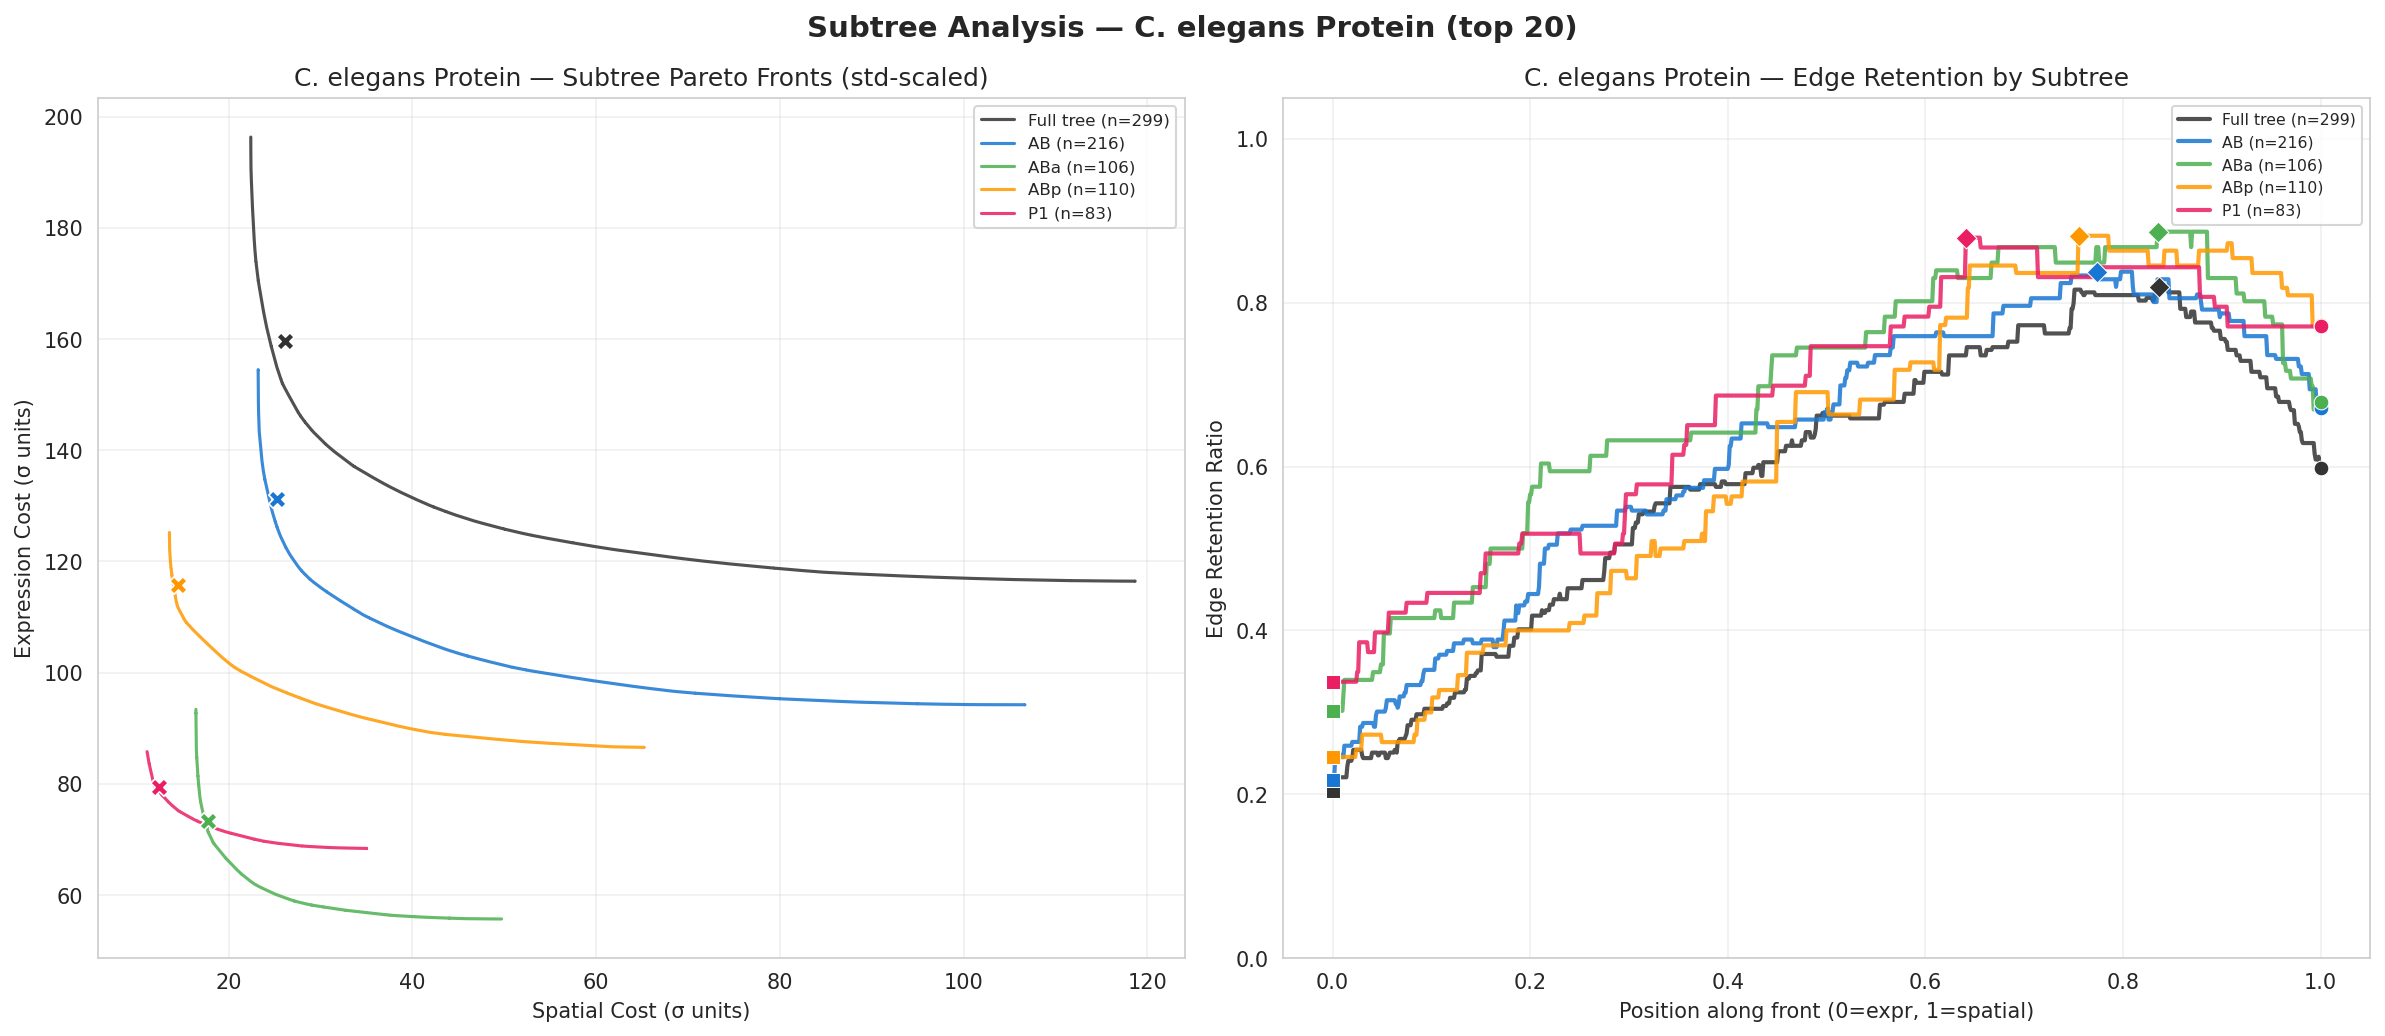

In [13]:
# ── Figure: Protein subtrees (std-based scaling) ──
sub_colors = {'Full tree': '#333', 'AB': '#1976D2', 'ABa': '#4CAF50', 'ABp': '#FF9800', 'P1': '#E91E63'}
fig, (ax_l, ax_r) = plt.subplots(1, 2, figsize=(16, 7))

for label in ['Full tree', 'AB', 'ABa', 'ABp', 'P1']:
    d = prot_sub[label]
    color = sub_colors[label]
    n = len(d['tn'])
    
    # Compute random stats for this subtree
    sub_groups = build_cousin_groups(d['tn'], gp_map)
    sub_rs = compute_cousin_random_stats(d['xm'], d['em'], sub_groups, n_random=300, seed=42)
    
    # Std-scaled Pareto front
    xyz_arr, exp_arr, edge_arr, kp = compute_std_scaled_pareto(d['xm'], d['em'], d['tp'], sub_rs)
    
    # Lineage position in std units
    lx = d['xm'].diagonal().sum() / sub_rs['xyz_std']
    le = d['em'].diagonal().sum() / sub_rs['exp_std']
    
    ax_l.plot(xyz_arr, exp_arr, color=color, lw=1.5, alpha=0.85, label=f'{label} (n={n})')
    ax_l.scatter(lx, le, color=color, marker='X', s=70, edgecolors='white', lw=0.8, zorder=6)
    ax_r.plot(x_front, edge_arr, color=color, lw=2, alpha=0.85, label=f'{label} (n={n})')
    for pk, mk in markers.items():
        idx = kp[pk]
        ax_r.scatter(x_front[idx], edge_arr[idx], color=color, marker=mk, s=50, zorder=8, edgecolors='white', lw=0.5)

ax_l.set_xlabel('Spatial Cost (σ units)')
ax_l.set_ylabel('Expression Cost (σ units)')
ax_l.set_title('C. elegans Protein — Subtree Pareto Fronts (std-scaled)', fontsize=12)
ax_l.legend(fontsize=8, loc='upper right')
ax_l.grid(True, alpha=0.3)
ax_r.set_xlabel('Position along front (0=expr, 1=spatial)')
ax_r.set_ylabel('Edge Retention Ratio')
ax_r.set_title('C. elegans Protein — Edge Retention by Subtree', fontsize=12)
ax_r.set_ylim(0, 1.05)
ax_r.grid(True, alpha=0.3)
ax_r.legend(fontsize=7.5, loc='best')
fig.suptitle('Subtree Analysis — C. elegans Protein (top 20)', fontsize=14, fontweight='bold')
fig.tight_layout()
plt.show()


### 2b. C. elegans — RNA-seq Expression (top 20 shared TFs)

In [14]:
# ── C. elegans RNA subtree analysis ──
er_sub = {}
for sroot in SUBTREES + ['Full']:
    label = sroot if sroot != 'Full' else 'Full tree'
    if sroot == 'Full':
        tn, tp = tn_er, tp_er
    else:
        tn, tp = collect_terminals(lineage_data, v_ce_rna, subtree=sroot)
    xm, em, _ = build_cost_matrices(tn, tp, xyz_ce, ce_rna, rna_sel)
    res = pareto_sweep(xm, em, tp)
    er_sub[label] = {'tn': tn, 'tp': tp, 'xm': xm, 'em': em, 'res': res}
    print(f"  {label:12s}: {len(tn):4d} cells | Expr ER={res['expr_opt_er']:.3f} | Max ER={res['max_er']:.3f} | Spatial ER={res['spatial_opt_er']:.3f}")

er_sub_df = pd.DataFrame({
    'Subtree': list(er_sub.keys()),
    'N Cells': [len(er_sub[k]['tn']) for k in er_sub],
    'Expr Opt ER': [er_sub[k]['res']['expr_opt_er'] for k in er_sub],
    'Max ER': [er_sub[k]['res']['max_er'] for k in er_sub],
    'Spatial Opt ER': [er_sub[k]['res']['spatial_opt_er'] for k in er_sub],
    'Closest Dist': [er_sub[k]['res']['closest_dist'] for k in er_sub],
}).set_index('Subtree')
er_sub_df


  AB          :  157 cells | Expr ER=0.083 | Max ER=0.936 | Spatial ER=0.911


  ABa         :   73 cells | Expr ER=0.137 | Max ER=0.945 | Spatial ER=0.945


  ABp         :   84 cells | Expr ER=0.107 | Max ER=0.952 | Spatial ER=0.952
  P1          :   74 cells | Expr ER=0.176 | Max ER=0.865 | Spatial ER=0.811


  Full tree   :  231 cells | Expr ER=0.074 | Max ER=0.805 | Spatial ER=0.684


,N Cells,Expr Opt ER,Max ER,Spatial Opt ER,Closest Dist
Subtree,,,,,
AB,157,0.082803,0.936306,0.910828,0.158576
ABa,73,0.136986,0.945205,0.945205,0.047887
ABp,84,0.107143,0.952381,0.952381,0.147439
P1,74,0.175676,0.864865,0.810811,0.200761
Full tree,231,0.073593,0.805195,0.683983,0.596727


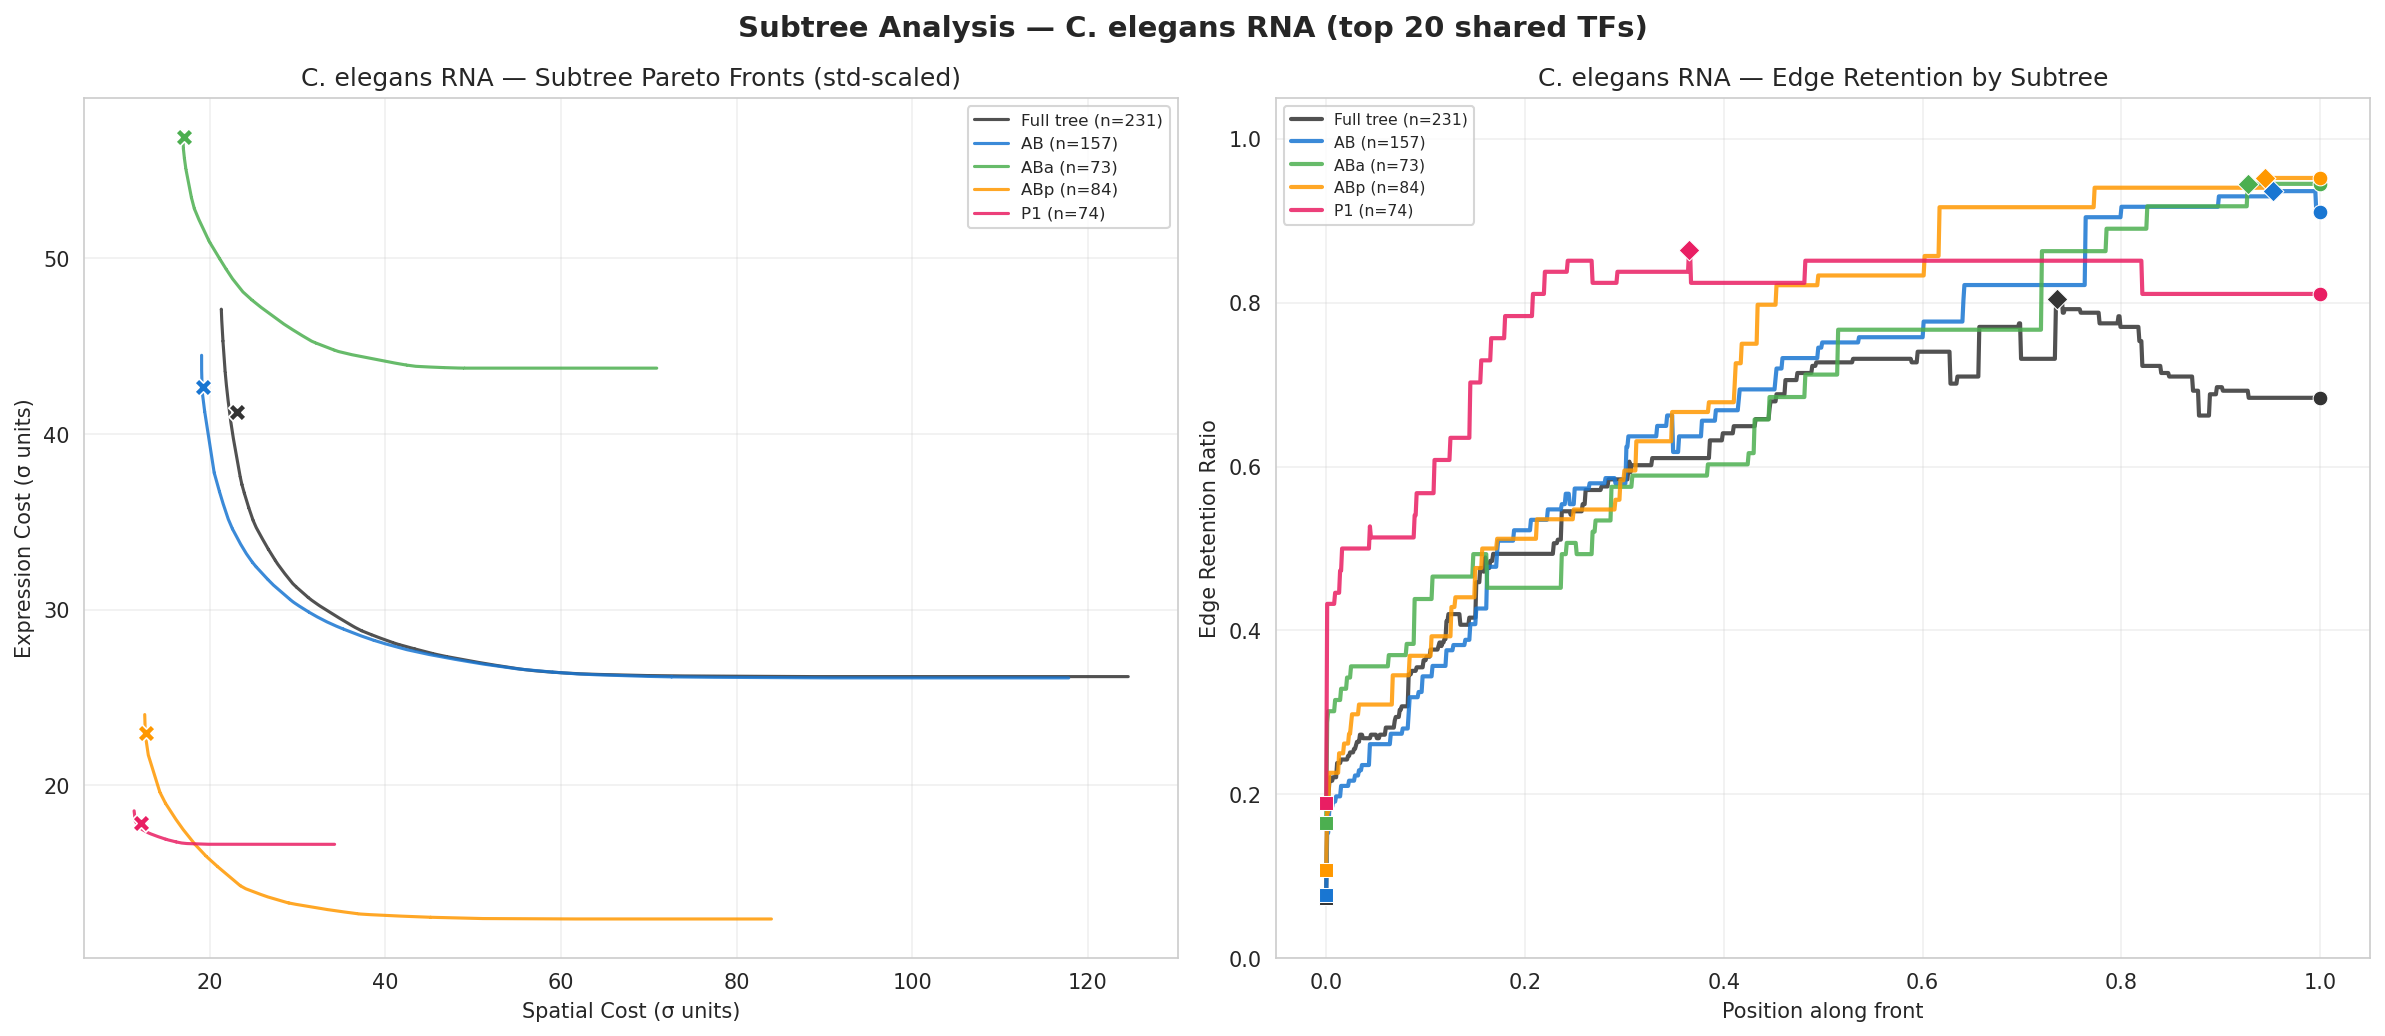

In [15]:
# ── Figure: C. elegans RNA subtrees (std-based scaling) ──
fig, (ax_l, ax_r) = plt.subplots(1, 2, figsize=(16, 7))
for label in ['Full tree', 'AB', 'ABa', 'ABp', 'P1']:
    d = er_sub[label]
    color = sub_colors[label]
    n = len(d['tn'])
    
    # Compute random stats for this subtree
    sub_groups = build_cousin_groups(d['tn'], gp_map)
    sub_rs = compute_cousin_random_stats(d['xm'], d['em'], sub_groups, n_random=300, seed=42)
    
    # Std-scaled Pareto front
    xyz_arr, exp_arr, edge_arr, kp = compute_std_scaled_pareto(d['xm'], d['em'], d['tp'], sub_rs)
    
    # Lineage position in std units
    lx = d['xm'].diagonal().sum() / sub_rs['xyz_std']
    le = d['em'].diagonal().sum() / sub_rs['exp_std']
    
    ax_l.plot(xyz_arr, exp_arr, color=color, lw=1.5, alpha=0.85, label=f'{label} (n={n})')
    ax_l.scatter(lx, le, color=color, marker='X', s=70, edgecolors='white', lw=0.8, zorder=6)
    ax_r.plot(x_front, edge_arr, color=color, lw=2, alpha=0.85, label=f'{label} (n={n})')
    for pk, mk in markers.items():
        idx = kp[pk]
        ax_r.scatter(x_front[idx], edge_arr[idx], color=color, marker=mk, s=50, zorder=8, edgecolors='white', lw=0.5)

ax_l.set_xlabel('Spatial Cost (σ units)')
ax_l.set_ylabel('Expression Cost (σ units)')
ax_l.set_title('C. elegans RNA — Subtree Pareto Fronts (std-scaled)', fontsize=12)
ax_l.legend(fontsize=8, loc='upper right')
ax_l.grid(True, alpha=0.3)
ax_r.set_xlabel('Position along front')
ax_r.set_ylabel('Edge Retention Ratio')
ax_r.set_title('C. elegans RNA — Edge Retention by Subtree', fontsize=12)
ax_r.set_ylim(0,1.05)
ax_r.grid(True, alpha=0.3)
ax_r.legend(fontsize=7.5, loc='best')
fig.suptitle('Subtree Analysis — C. elegans RNA (top 20 shared TFs)', fontsize=14, fontweight='bold')
fig.tight_layout()
plt.show()


### 2c. C. briggsae — RNA-seq Expression (top 20 shared TFs)

In [16]:
# ── C. briggsae RNA subtree analysis ──
cb_sub = {}
for sroot in SUBTREES + ['Full']:
    label = sroot if sroot != 'Full' else 'Full tree'
    if sroot == 'Full':
        tn, tp = tn_cb, tp_cb
    else:
        tn, tp = collect_terminals(lineage_data, v_cb_rna, subtree=sroot)
    xm, em, _ = build_cost_matrices(tn, tp, xyz_cb, cb_rna, rna_sel)
    res = pareto_sweep(xm, em, tp)
    cb_sub[label] = {'tn': tn, 'tp': tp, 'xm': xm, 'em': em, 'res': res}
    print(f"  {label:12s}: {len(tn):4d} cells | Expr ER={res['expr_opt_er']:.3f} | Max ER={res['max_er']:.3f} | Spatial ER={res['spatial_opt_er']:.3f}")

cb_sub_df = pd.DataFrame({
    'Subtree': list(cb_sub.keys()),
    'N Cells': [len(cb_sub[k]['tn']) for k in cb_sub],
    'Expr Opt ER': [cb_sub[k]['res']['expr_opt_er'] for k in cb_sub],
    'Max ER': [cb_sub[k]['res']['max_er'] for k in cb_sub],
    'Spatial Opt ER': [cb_sub[k]['res']['spatial_opt_er'] for k in cb_sub],
    'Closest Dist': [cb_sub[k]['res']['closest_dist'] for k in cb_sub],
}).set_index('Subtree')
cb_sub_df


  AB          :   37 cells | Expr ER=0.243 | Max ER=0.892 | Spatial ER=0.838
  ABa         :   21 cells | Expr ER=0.381 | Max ER=1.000 | Spatial ER=0.905
  ABp         :   16 cells | Expr ER=0.250 | Max ER=1.000 | Spatial ER=0.875
  P1          :   32 cells | Expr ER=0.375 | Max ER=0.688 | Spatial ER=0.625


  Full tree   :   69 cells | Expr ER=0.130 | Max ER=0.754 | Spatial ER=0.493


,N Cells,Expr Opt ER,Max ER,Spatial Opt ER,Closest Dist
Subtree,,,,,
AB,37,0.243243,0.891892,0.837838,0.040276
ABa,21,0.380952,1.000000,0.904762,0.000000
ABp,16,0.250000,1.000000,0.875000,0.000000
P1,32,0.375000,0.687500,0.625000,0.146396
Full tree,69,0.130435,0.753623,0.492754,0.244804


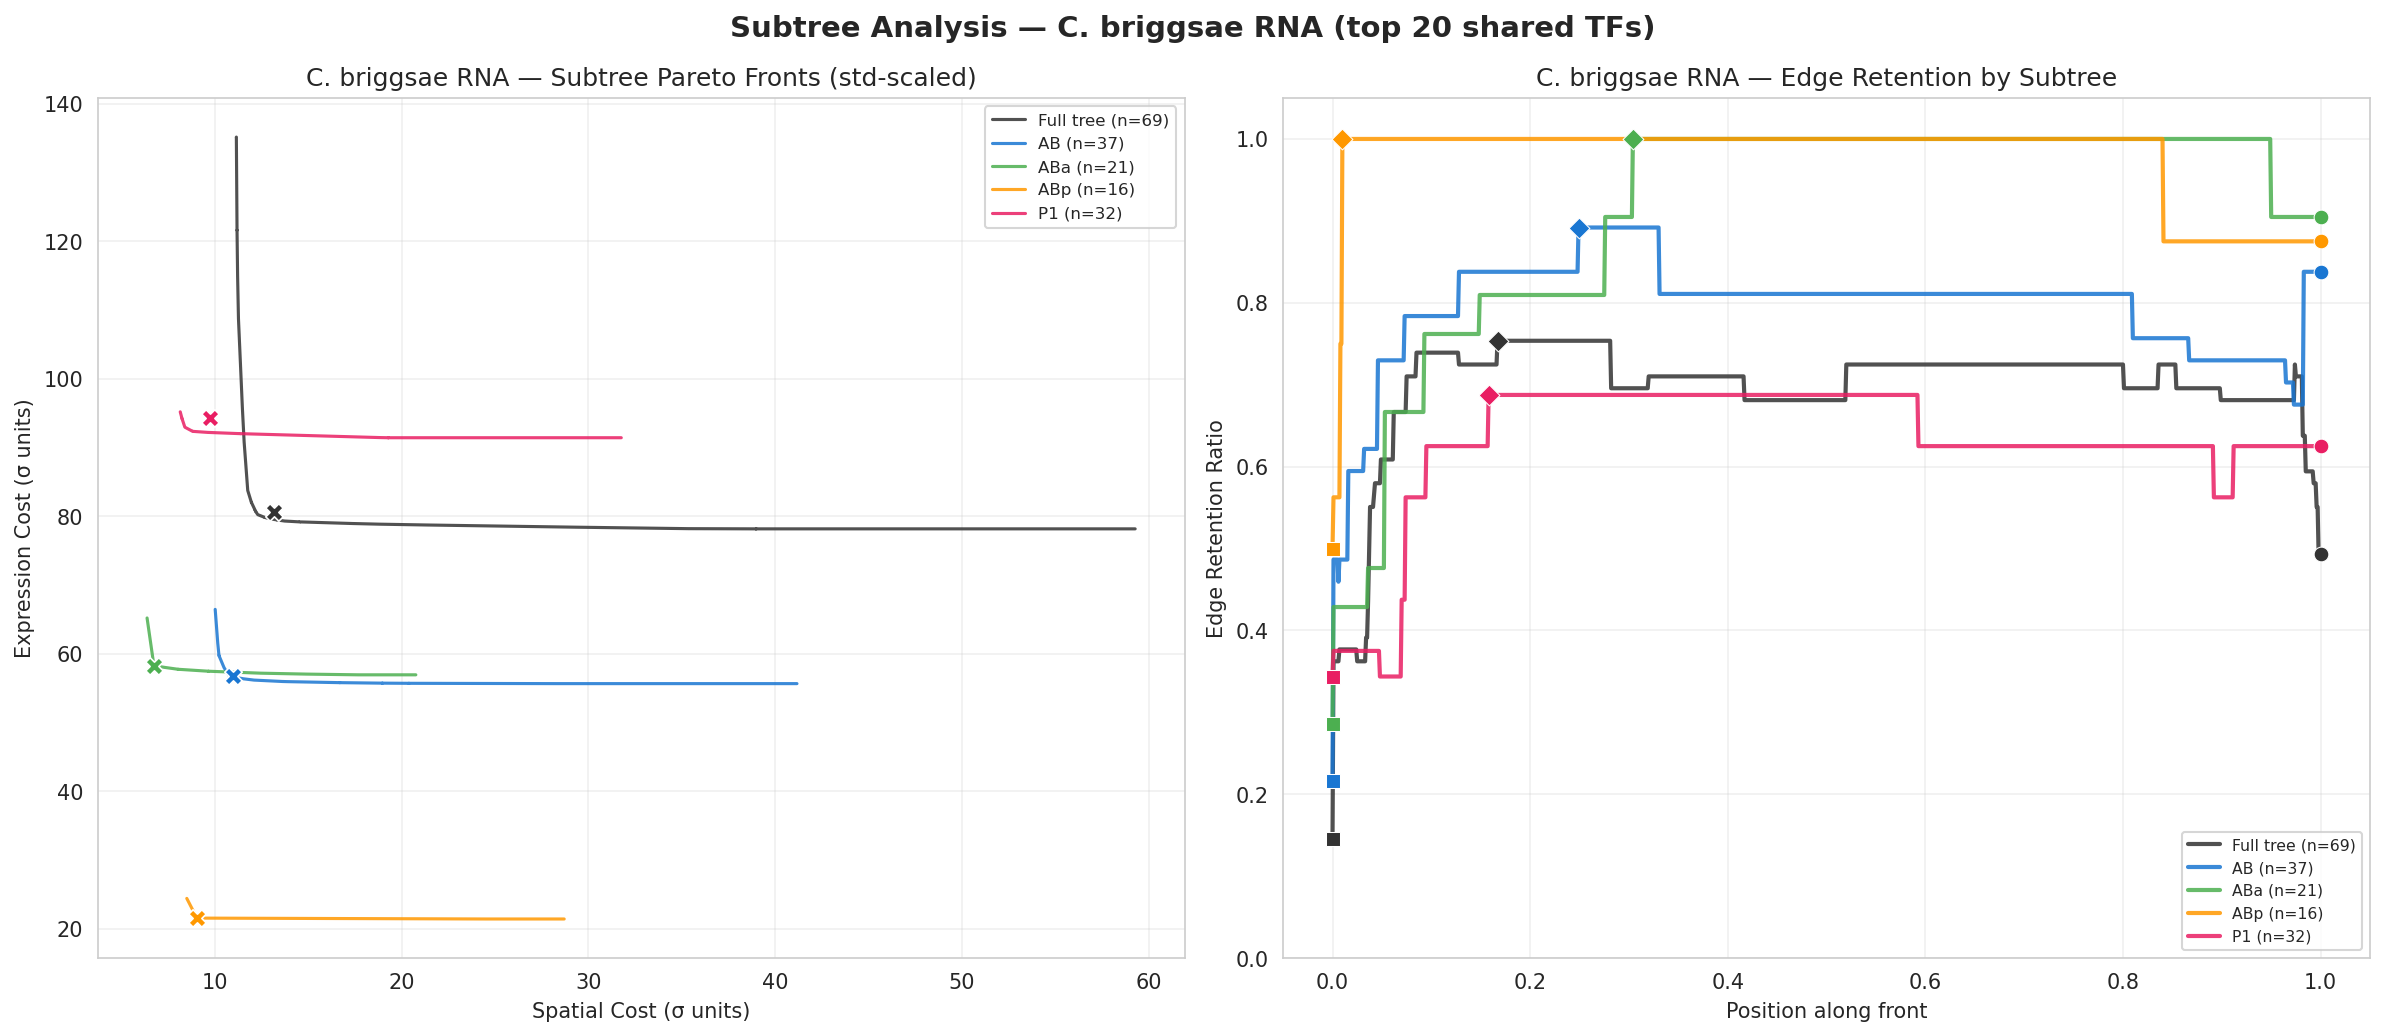

In [17]:
# ── Figure: C. briggsae RNA subtrees (std-based scaling) ──
fig, (ax_l, ax_r) = plt.subplots(1, 2, figsize=(16, 7))
for label in ['Full tree', 'AB', 'ABa', 'ABp', 'P1']:
    d = cb_sub[label]
    color = sub_colors[label]
    n = len(d['tn'])
    
    # Compute random stats for this subtree
    sub_groups = build_cousin_groups(d['tn'], gp_map)
    sub_rs = compute_cousin_random_stats(d['xm'], d['em'], sub_groups, n_random=300, seed=42)
    
    # Std-scaled Pareto front
    xyz_arr, exp_arr, edge_arr, kp = compute_std_scaled_pareto(d['xm'], d['em'], d['tp'], sub_rs)
    
    # Lineage position in std units
    lx = d['xm'].diagonal().sum() / sub_rs['xyz_std']
    le = d['em'].diagonal().sum() / sub_rs['exp_std']
    
    ax_l.plot(xyz_arr, exp_arr, color=color, lw=1.5, alpha=0.85, label=f'{label} (n={n})')
    ax_l.scatter(lx, le, color=color, marker='X', s=70, edgecolors='white', lw=0.8, zorder=6)
    ax_r.plot(x_front, edge_arr, color=color, lw=2, alpha=0.85, label=f'{label} (n={n})')
    for pk, mk in markers.items():
        idx = kp[pk]
        ax_r.scatter(x_front[idx], edge_arr[idx], color=color, marker=mk, s=50, zorder=8, edgecolors='white', lw=0.5)

ax_l.set_xlabel('Spatial Cost (σ units)')
ax_l.set_ylabel('Expression Cost (σ units)')
ax_l.set_title('C. briggsae RNA — Subtree Pareto Fronts (std-scaled)', fontsize=12)
ax_l.legend(fontsize=8, loc='upper right')
ax_l.grid(True, alpha=0.3)
ax_r.set_xlabel('Position along front')
ax_r.set_ylabel('Edge Retention Ratio')
ax_r.set_title('C. briggsae RNA — Edge Retention by Subtree', fontsize=12)
ax_r.set_ylim(0,1.05)
ax_r.grid(True, alpha=0.3)
ax_r.legend(fontsize=7.5, loc='best')
fig.suptitle('Subtree Analysis — C. briggsae RNA (top 20 shared TFs)', fontsize=14, fontweight='bold')
fig.tight_layout()
plt.show()


### 2d. Cross-Dataset Subtree Comparison

In [18]:
# ── Side-by-side Expr Opt ER comparison across datasets ──
print(f"{'Subtree':12s} | {'Protein ER':12s} | {'C.elegans RNA ER':16s} | {'C.briggsae RNA ER':16s}")
print("-" * 70)
for label in ['Full tree', 'AB', 'ABa', 'ABp', 'P1']:
    pe = prot_sub[label]['res']['expr_opt_er']
    ee = er_sub[label]['res']['expr_opt_er']
    ce = cb_sub[label]['res']['expr_opt_er']
    print(f"{label:12s} | {pe:.3f}         | {ee:.3f}              | {ce:.3f}")

print(f"\n{'Subtree':12s} | {'Protein Max ER':14s} | {'C.elegans RNA Max ER':18s} | {'C.briggsae RNA Max ER':18s}")
print("-" * 75)
for label in ['Full tree', 'AB', 'ABa', 'ABp', 'P1']:
    pe = prot_sub[label]['res']['max_er']
    ee = er_sub[label]['res']['max_er']
    ce = cb_sub[label]['res']['max_er']
    print(f"{label:12s} | {pe:.3f}           | {ee:.3f}                | {ce:.3f}")


Subtree      | Protein ER   | C.elegans RNA ER | C.briggsae RNA ER
----------------------------------------------------------------------
Full tree    | 0.204         | 0.074              | 0.130
AB           | 0.218         | 0.083              | 0.243
ABa          | 0.302         | 0.137              | 0.381
ABp          | 0.245         | 0.107              | 0.250
P1           | 0.337         | 0.176              | 0.375

Subtree      | Protein Max ER | C.elegans RNA Max ER | C.briggsae RNA Max ER
---------------------------------------------------------------------------
Full tree    | 0.819           | 0.805                | 0.754
AB           | 0.838           | 0.936                | 0.892
ABa          | 0.887           | 0.945                | 1.000
ABp          | 0.882           | 0.952                | 1.000
P1           | 0.880           | 0.865                | 0.688


### 2e. Extended Subtree Analysis — C. elegans Protein (top 20)

All 47 lineage subtrees with >10 terminal cells.  Each subtree is annotated with its
**dominant cell type** to reveal how type purity affects the Pareto metrics.

In [19]:
# ── Cell type loading (compact, inline for this section) ──
MERGE_MAP = {
    'neuron':'neuron','muscle':'muscle','repro':'reproduction',
    'hypoderm':'epithelium','epithelium':'epithelium',
    'sheath':'glial','socket':'glial','coelomocyte':'coelomocyte',
    'excretory':'excretory','mesoderm':'mesoderm','other':'other',
    'intestine':'alimentary','valve':'alimentary','marginal':'alimentary',
    'gland':'alimentary','rectal':'alimentary',
    'tail':'programmed_death','programmed_death':'programmed_death','blast':'programmed_death',
}
_ct_df = pd.read_csv('data/2023-06-29_entropy_cell_key_V2.csv')
_lineage_to_type = {}
for _, row in _ct_df.iterrows():
    ln = row.get('wormweb.lineage',''); rt = row.get('wormweb.type','')
    if pd.notna(rt) and rt.strip():
        _lineage_to_type[ln] = MERGE_MAP.get(rt.strip(), rt.strip())
def get_ct(lin): return _lineage_to_type.get(lin, 'programmed_death')

# ── Enumerate all subtrees with >10 terminal cells ──
terminal_descendants = {}

def postorder_collect(node, parent=None):
    children = node.get("children", [])
    lookup_name = map_names(node["did"])
    my_terms = []
    if len(children) == 0:
        p_lookup_name = map_names(parent['did']) if parent else None
        if (lookup_name in v_prot and p_lookup_name in v_prot):
            my_terms.append((lookup_name, p_lookup_name))
    else:
        for child in children:
            my_terms.extend(postorder_collect(child, node))
    terminal_descendants[lookup_name] = my_terms
    return my_terms

postorder_collect(lineage_data)
qualifying = [(n, t) for n, t in terminal_descendants.items() if len(t) >= 10]
qualifying.sort(key=lambda x: -len(x[1]))
print(f"Subtrees with >=10 terminal cells: {len(qualifying)}")

# ── Run Pareto for each ──
ext_sub = {}
for sname, term_list in qualifying:
    tn = [t[0] for t in term_list]; tp = [t[1] for t in term_list]; n = len(tn)
    # Cell type composition
    tc = defaultdict(int)
    for node in tn: tc[get_ct(node)] += 1
    dtype = max(tc, key=tc.get); dfrac = tc[dtype] / n
    xm, em, _ = build_cost_matrices(tn, tp, xyz_ce, protein_exp, prot_sel)
    res = pareto_sweep(xm, em, tp)
    ext_sub[sname] = {'tn': tn, 'tp': tp, 'xm': xm, 'em': em, 'res': res,
                      'n': n, 'dominant_type': dtype, 'dominant_frac': dfrac, 'type_dist': dict(tc)}

print(f"Ran Pareto for {len(ext_sub)} subtrees")


Subtrees with >=10 terminal cells: 49


Ran Pareto for 49 subtrees


In [20]:
# ── Extended subtree summary table (top 25 by size) ──
ext_rows = []
for name in sorted(ext_sub, key=lambda k: -ext_sub[k]['n']):
    d = ext_sub[name]; r = d['res']
    type_str = ', '.join(f'{t}({c})' for t, c in sorted(d['type_dist'].items(), key=lambda x: -x[1])[:3])
    ext_rows.append({
        'Subtree': name, 'N': d['n'],
        'Expr Opt ER': round(r['expr_opt_er'], 3), 'Max ER': round(r['max_er'], 3),
        'Spatial Opt ER': round(r['spatial_opt_er'], 3), 'Closest Dist': round(r['closest_dist'], 3),
        'Dominant Type': d['dominant_type'], 'Dom. Frac': round(d['dominant_frac'], 2),
        'Top 3 Types': type_str,
    })
ext_df = pd.DataFrame(ext_rows).set_index('Subtree')
print(f"Total subtrees: {len(ext_df)}")
ext_df.head(25)


Total subtrees: 49


,N,Expr Opt ER,Max ER,Spatial Opt ER,Closest Dist,Dominant Type,Dom. Frac,Top 3 Types
Subtree,,,,,,,,
P0,299,0.204,0.819,0.599,1.132,neuron,0.32,"neuron(97), muscle(61), epithelium(57)"
AB,216,0.218,0.838,0.671,0.464,neuron,0.44,"neuron(95), epithelium(44), programmed_death(27)"
ABp,110,0.245,0.882,0.773,0.348,neuron,0.54,"neuron(59), epithelium(24), programmed_death(12)"
ABa,106,0.302,0.887,0.679,0.175,neuron,0.34,"neuron(36), epithelium(20), programmed_death(15)"
P1,83,0.337,0.880,0.771,0.191,muscle,0.59,"muscle(49), epithelium(13), alimentary(9)"
ABpr,60,0.367,0.867,0.800,0.262,neuron,0.62,"neuron(37), epithelium(9), programmed_death(6)"
ABal,59,0.424,0.932,0.780,0.273,neuron,0.44,"neuron(26), programmed_death(11), glial(9)"
EMS,55,0.327,0.909,0.800,0.114,muscle,0.67,"muscle(37), alimentary(9), programmed_death(7)"
MS,53,0.302,0.906,0.792,0.114,muscle,0.70,"muscle(37), alimentary(7), programmed_death(7)"


In [21]:
# ── Subtrees dominated (>70%) by a single cell type ──
dominated = ext_df[ext_df['Dom. Frac'] >= 0.7].sort_values('Dom. Frac', ascending=False)
print(f"Subtrees with >70% single cell type: {len(dominated)}")
dominated[['N', 'Expr Opt ER', 'Max ER', 'Spatial Opt ER', 'Dominant Type', 'Dom. Frac']].head(15)


Subtrees with >70% single cell type: 17


,N,Expr Opt ER,Max ER,Spatial Opt ER,Dominant Type,Dom. Frac
Subtree,,,,,,
D,12,0.417,0.833,0.833,muscle,1.00
C,14,0.286,0.786,0.786,epithelium,0.93
ABprpaa,11,0.636,1.000,0.818,neuron,0.91
ABplpaa,10,1.000,1.000,1.000,neuron,0.90
P3,14,0.500,0.857,0.857,muscle,0.86
ABprpa,27,0.556,0.926,0.852,neuron,0.85
ABarpa,11,0.364,1.000,0.818,epithelium,0.82
ABprpap,16,0.500,0.875,0.875,neuron,0.81
ABarapp,10,0.600,1.000,1.000,neuron,0.80


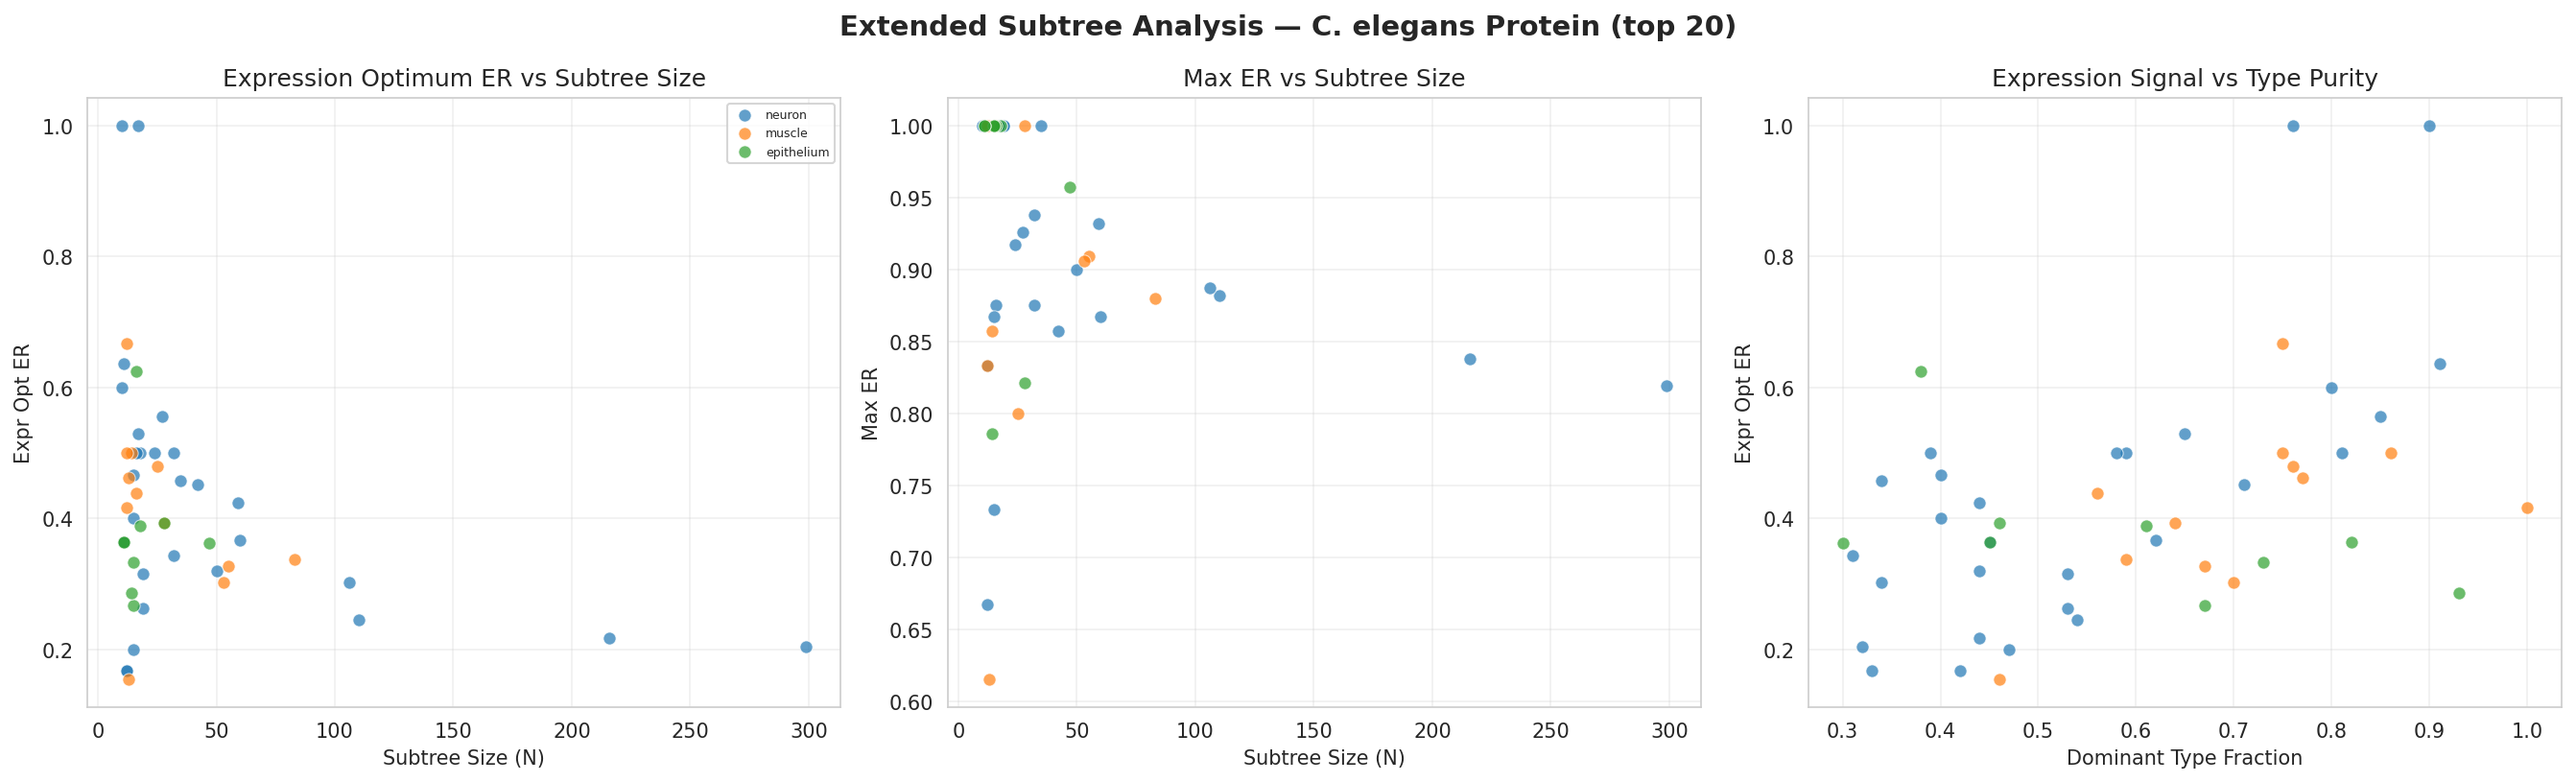

In [22]:
# ── Scatter: Pareto metrics vs subtree size & type purity ──
fig, axes = plt.subplots(1, 3, figsize=(18, 5.5))
type_list = ext_df['Dominant Type'].unique()
type_colors = {t: plt.cm.tab10(i % 10) for i, t in enumerate(type_list)}

# 1) Expr Opt ER vs N
ax = axes[0]
for t in type_list:
    mask = ext_df['Dominant Type'] == t
    ax.scatter(ext_df.loc[mask, 'N'], ext_df.loc[mask, 'Expr Opt ER'],
               c=[type_colors[t]], label=t, s=40, alpha=0.7, edgecolors='white', linewidth=0.5)
ax.set_xlabel('Subtree Size (N)'); ax.set_ylabel('Expr Opt ER')
ax.set_title('Expression Optimum ER vs Subtree Size'); ax.legend(fontsize=6, loc='best'); ax.grid(True, alpha=0.3)

# 2) Max ER vs N
ax = axes[1]
for t in type_list:
    mask = ext_df['Dominant Type'] == t
    ax.scatter(ext_df.loc[mask, 'N'], ext_df.loc[mask, 'Max ER'],
               c=[type_colors[t]], label=t, s=40, alpha=0.7, edgecolors='white', linewidth=0.5)
ax.set_xlabel('Subtree Size (N)'); ax.set_ylabel('Max ER')
ax.set_title('Max ER vs Subtree Size'); ax.grid(True, alpha=0.3)

# 3) Expr Opt ER vs Dom. Frac
ax = axes[2]
for t in type_list:
    mask = ext_df['Dominant Type'] == t
    ax.scatter(ext_df.loc[mask, 'Dom. Frac'], ext_df.loc[mask, 'Expr Opt ER'],
               c=[type_colors[t]], label=t, s=40, alpha=0.7, edgecolors='white', linewidth=0.5)
ax.set_xlabel('Dominant Type Fraction'); ax.set_ylabel('Expr Opt ER')
ax.set_title('Expression Signal vs Type Purity'); ax.grid(True, alpha=0.3)

fig.suptitle('Extended Subtree Analysis — C. elegans Protein (top 20)', fontsize=14, fontweight='bold')
fig.tight_layout(); plt.show()


---
## 3. Cell Type Analysis — C. elegans Protein (top 20)

Terminal cells are partitioned by their WormWeb cell type annotation.
Top 3 types (neuron, muscle, epithelium) shown individually, plus
remaining minor types bundled as "rest" and apoptotic cells as a separate group.

In [23]:
# ── Cell type loading ──
MERGE_MAP = {
    'neuron':'neuron','muscle':'muscle','repro':'reproduction',
    'hypoderm':'epithelium','epithelium':'epithelium',
    'sheath':'glial','socket':'glial','coelomocyte':'coelomocyte',
    'excretory':'excretory','mesoderm':'mesoderm','other':'other',
    'intestine':'alimentary','valve':'alimentary','marginal':'alimentary',
    'gland':'alimentary','rectal':'alimentary',
    'tail':'programmed_death','programmed_death':'programmed_death','blast':'programmed_death',
}
ct_df = pd.read_csv('data/2023-06-29_entropy_cell_key_V2.csv')
lineage_to_type = {}
for _, row in ct_df.iterrows():
    ln = row.get('wormweb.lineage',''); rt = row.get('wormweb.type','')
    if pd.notna(rt) and rt.strip():
        lineage_to_type[ln] = MERGE_MAP.get(rt.strip(), rt.strip())

def get_type(lin): return lineage_to_type.get(lin, 'programmed_death')

# Map protein terminal cells to types
type_counts = defaultdict(int)
node_type = {}
for n in tn_prot:
    ct = get_type(n); node_type[n] = ct; type_counts[ct] += 1

sorted_types = sorted(type_counts.items(), key=lambda x: -x[1])
print("Cell type distribution:")
for ct, cnt in sorted_types: print(f"  {ct:20s}: {cnt:4d}")

# Top 3 + rest + apoptotic
non_apop = [(ct,cnt) for ct,cnt in sorted_types if ct != 'programmed_death']
apop_cnt = type_counts.get('programmed_death', 0)
top3 = non_apop[:3]
rest_cnt = sum(cnt for ct,cnt in non_apop[3:])
groups = [(ct,cnt) for ct,cnt in top3] + [('rest (other types)', rest_cnt), ('programmed_death', apop_cnt)]

print(f"\nAnalysis groups:")
for ct, cnt in groups: print(f"  {ct:20s}: {cnt:4d}")


Cell type distribution:
  neuron              :   97
  muscle              :   61
  epithelium          :   57
  programmed_death    :   34
  glial               :   20
  alimentary          :   20
  excretory           :    4
  other               :    3
  reproduction        :    2
  mesoderm            :    1

Analysis groups:
  neuron              :   97
  muscle              :   61
  epithelium          :   57
  rest (other types)  :   50
  programmed_death    :   34


In [24]:
# ── Run Pareto for each cell type group ──
ct_results = {}
for gname, _ in groups:
    if gname == 'rest (other types)':
        included = set(ct for ct,cnt in non_apop[3:])
    elif gname == 'programmed_death':
        included = {'programmed_death'}
    else:
        included = {gname}

    gn, gp = [], []
    for n, p in zip(tn_prot, tp_prot):
        if node_type.get(n, 'programmed_death') in included and n in xyz_ce and p in xyz_ce:
            gn.append(n); gp.append(p)

    if len(gn) < 10:
        print(f"  {gname}: {len(gn)} cells — too few, skipping")
        continue

    xm, em, _ = build_cost_matrices(gn, gp, xyz_ce, protein_exp, prot_sel)
    res = pareto_sweep(xm, em, gp)
    ct_results[gname] = {'tn': gn, 'tp': gp, 'xm': xm, 'em': em, 'res': res}
    print(f"  {gname:20s}: {len(gn):4d} cells | Expr ER={res['expr_opt_er']:.3f} | Max ER={res['max_er']:.3f} | Spatial ER={res['spatial_opt_er']:.3f}")

ct_df = pd.DataFrame({
    'Cell Type': list(ct_results.keys()),
    'N Cells': [len(ct_results[k]['tn']) for k in ct_results],
    'Expr Opt ER': [ct_results[k]['res']['expr_opt_er'] for k in ct_results],
    'Max ER': [ct_results[k]['res']['max_er'] for k in ct_results],
    'Spatial Opt ER': [ct_results[k]['res']['spatial_opt_er'] for k in ct_results],
    'Closest Dist': [ct_results[k]['res']['closest_dist'] for k in ct_results],
}).set_index('Cell Type')
ct_df


  neuron              :   97 cells | Expr ER=0.227 | Max ER=0.938 | Spatial ER=0.897
  muscle              :   61 cells | Expr ER=0.311 | Max ER=0.902 | Spatial ER=0.754


  epithelium          :   57 cells | Expr ER=0.193 | Max ER=0.947 | Spatial ER=0.912
  rest (other types)  :   50 cells | Expr ER=0.420 | Max ER=1.000 | Spatial ER=0.960
  programmed_death    :   34 cells | Expr ER=0.353 | Max ER=0.824 | Spatial ER=0.706


,N Cells,Expr Opt ER,Max ER,Spatial Opt ER,Closest Dist
Cell Type,,,,,
neuron,97,0.226804,0.938144,0.896907,0.042358
muscle,61,0.311475,0.901639,0.754098,0.132772
epithelium,57,0.192982,0.947368,0.912281,0.086565
rest (other types),50,0.420000,1.000000,0.960000,0.000000
programmed_death,34,0.352941,0.823529,0.705882,0.108225


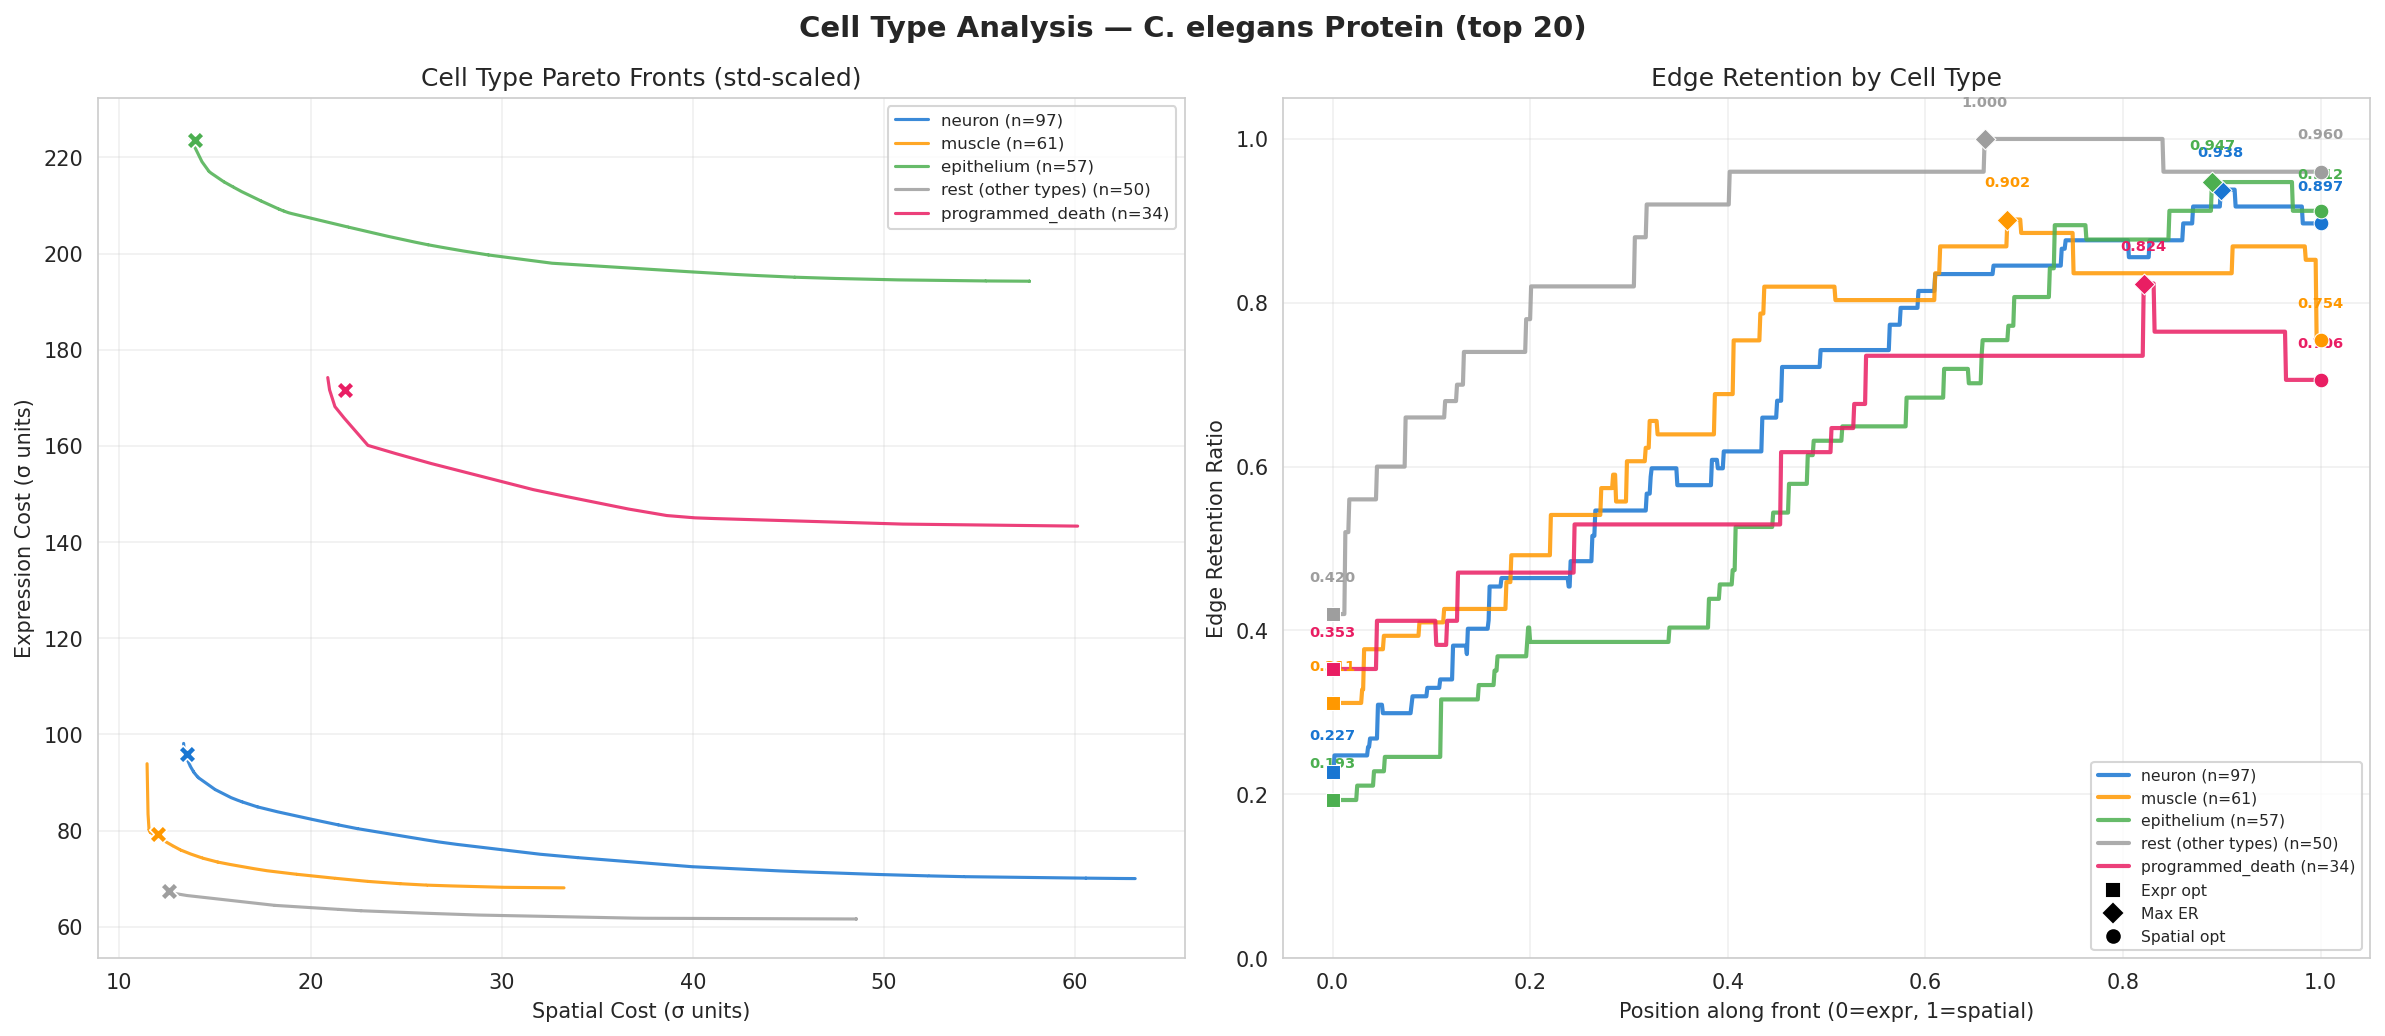

In [25]:
# ── Figure: Cell type Pareto fronts (std-based scaling) ──
ct_colors = {'neuron': '#1976D2', 'muscle': '#FF9800', 'epithelium': '#4CAF50',
             'rest (other types)': '#9E9E9E', 'programmed_death': '#E91E63'}

fig, (ax_l, ax_r) = plt.subplots(1, 2, figsize=(16, 7))
for gname in ct_results:
    d = ct_results[gname]
    color = ct_colors.get(gname, 'gray')
    
    # Compute random stats for this cell type
    sub_groups = build_cousin_groups(d['tn'], gp_map)
    sub_rs = compute_cousin_random_stats(d['xm'], d['em'], sub_groups, n_random=300, seed=42)
    
    # Std-scaled Pareto front
    xyz_arr, exp_arr, edge_arr, kp = compute_std_scaled_pareto(d['xm'], d['em'], d['tp'], sub_rs)
    n = len(d['tn'])
    
    # Lineage position in std units
    lx = d['xm'].diagonal().sum() / sub_rs['xyz_std']
    le = d['em'].diagonal().sum() / sub_rs['exp_std']
    
    ax_l.plot(xyz_arr, exp_arr, color=color, lw=1.5, alpha=0.85, label=f'{gname} (n={n})')
    ax_l.scatter(lx, le, color=color, marker='X', s=70, edgecolors='white', lw=0.8, zorder=6)
    ax_r.plot(x_front, edge_arr, color=color, lw=2, alpha=0.85, label=f'{gname} (n={n})')
    for pk, mk in markers.items():
        idx = kp[pk]
        ax_r.scatter(x_front[idx], edge_arr[idx], color=color, marker=mk, s=50, zorder=8, edgecolors='white', lw=0.5)
        ax_r.annotate(f'{edge_arr[idx]:.3f}', (x_front[idx], edge_arr[idx]+0.04), color=color, fontsize=7, ha='center', fontweight='bold')

ax_l.set_xlabel('Spatial Cost (σ units)')
ax_l.set_ylabel('Expression Cost (σ units)')
ax_l.set_title('Cell Type Pareto Fronts (std-scaled)', fontsize=12)
ax_l.legend(fontsize=8, loc='upper right')
ax_l.grid(True, alpha=0.3)
ax_r.set_xlabel('Position along front (0=expr, 1=spatial)')
ax_r.set_ylabel('Edge Retention Ratio')
ax_r.set_title('Edge Retention by Cell Type', fontsize=12)
ax_r.set_ylim(0,1.05)
ax_r.grid(True, alpha=0.3)
ax_r.legend(handles=list(ax_r.get_lines()) + [
    Line2D([0],[0], color='black', marker='s', ls='', markersize=6, label='Expr opt'),
    Line2D([0],[0], color='black', marker='D', ls='', markersize=6, label='Max ER'),
    Line2D([0],[0], color='black', marker='o', ls='', markersize=6, label='Spatial opt'),
], fontsize=7.5, loc='best')
fig.suptitle('Cell Type Analysis — C. elegans Protein (top 20)', fontsize=14, fontweight='bold')
fig.tight_layout()
plt.show()


### 3b. Relaxed Parent Pool — Per-Type Analysis

For each cell type, we compare the **type-restricted** Pareto front (only type-matched parents)
against a **relaxed** version where terminal cells can be assigned to **any** terminal parent
in the full tree.  The relaxed version is an upper bound — it shows how much better the
assignment could be if we dropped the type constraint.

In [26]:
# ── Relaxed parent pool: for each type, assign to ANY parent ──
# Get ALL terminal parents from the full protein tree
all_parents = list(dict.fromkeys(tp_prot))  # unique parents from full tree (terminal + internal nodes)
all_parents_set = set(all_parents)

relaxed_results = {}
for gname in ct_results:
    d = ct_results[gname]
    gn = d['tn']  # terminal cells of this type
    gp = d['tp']  # real parents of these cells
    n_type = len(gn)

    if n_type < 10:
        continue

    # Build rectangular cost matrix: n_parent_candidates x n_type_terminals
    # Initialize with large values to exclude invalid candidates
    BIG = 1e10
    xm_relax = np.full((len(all_parents), n_type), BIG)
    em_relax = np.full((len(all_parents), n_type), BIG)
    for i, parent_candidate in enumerate(all_parents):
        if parent_candidate not in xyz_ce or parent_candidate not in protein_exp.index:
            continue  # skip parents without tracking or expression data
        for j, node in enumerate(gn):
            xm_relax[i, j] = np.linalg.norm(xyz_ce[parent_candidate] - xyz_ce[node])
            em_relax[i, j] = cosine(
                protein_exp.loc[parent_candidate, prot_sel].values,
                protein_exp.loc[node, prot_sel].values
            )

    # Normalize (min-max)
    xm_n = (xm_relax - xm_relax.min()) / (xm_relax.max() - xm_relax.min())
    em_n = (em_relax - em_relax.min()) / (em_relax.max() - em_relax.min())

    # Pareto sweep
    relaxed_edges = []
    for i in range(1001):
        a = i / 1000
        ri, ci = linear_sum_assignment(a * xm_n + (1 - a) * em_n)
        # Edge retention: fraction where assigned parent == real parent
        edges = 0
        for r, c in zip(ri, ci):
            if all_parents[r] == gp[c]:
                edges += 1
        relaxed_edges.append(edges / n_type)

    relaxed_edges = np.array(relaxed_edges)
    # Also compute type-restricted edge ratios (reuse from ct_results but recompute along front)
    xm_r, em_r = d['xm'], d['em']
    xm_rn = (xm_r - xm_r.min()) / (xm_r.max() - xm_r.min())
    em_rn = (em_r - em_r.min()) / (em_r.max() - em_r.min())
    restricted_edges = []
    for i in range(1001):
        a = i / 1000
        ri, ci = linear_sum_assignment(a * xm_rn + (1 - a) * em_rn)
        edges = sum(1 for r, c in zip(ri, ci) if d['tp'][r] == d['tp'][c]) / n_type
        restricted_edges.append(edges)

    relaxed_results[gname] = {
        'relaxed_edges': relaxed_edges,
        'restricted_edges': np.array(restricted_edges),
        'n': n_type,
        'restricted_res': d['res'],
    }

    rlx_max = relaxed_edges.max()
    rst_max = d['res']['max_er']
    print(f"  {gname:20s}: n={n_type:3d} | restricted Max ER={rst_max:.3f} | relaxed Max ER={rlx_max:.3f} | gain={rlx_max-rst_max:+.3f}")


  neuron              : n= 97 | restricted Max ER=0.938 | relaxed Max ER=0.629 | gain=-0.309


  muscle              : n= 61 | restricted Max ER=0.902 | relaxed Max ER=0.475 | gain=-0.426


  epithelium          : n= 57 | restricted Max ER=0.947 | relaxed Max ER=0.509 | gain=-0.439


  rest (other types)  : n= 50 | restricted Max ER=1.000 | relaxed Max ER=0.860 | gain=-0.140


  programmed_death    : n= 34 | restricted Max ER=0.824 | relaxed Max ER=0.529 | gain=-0.294


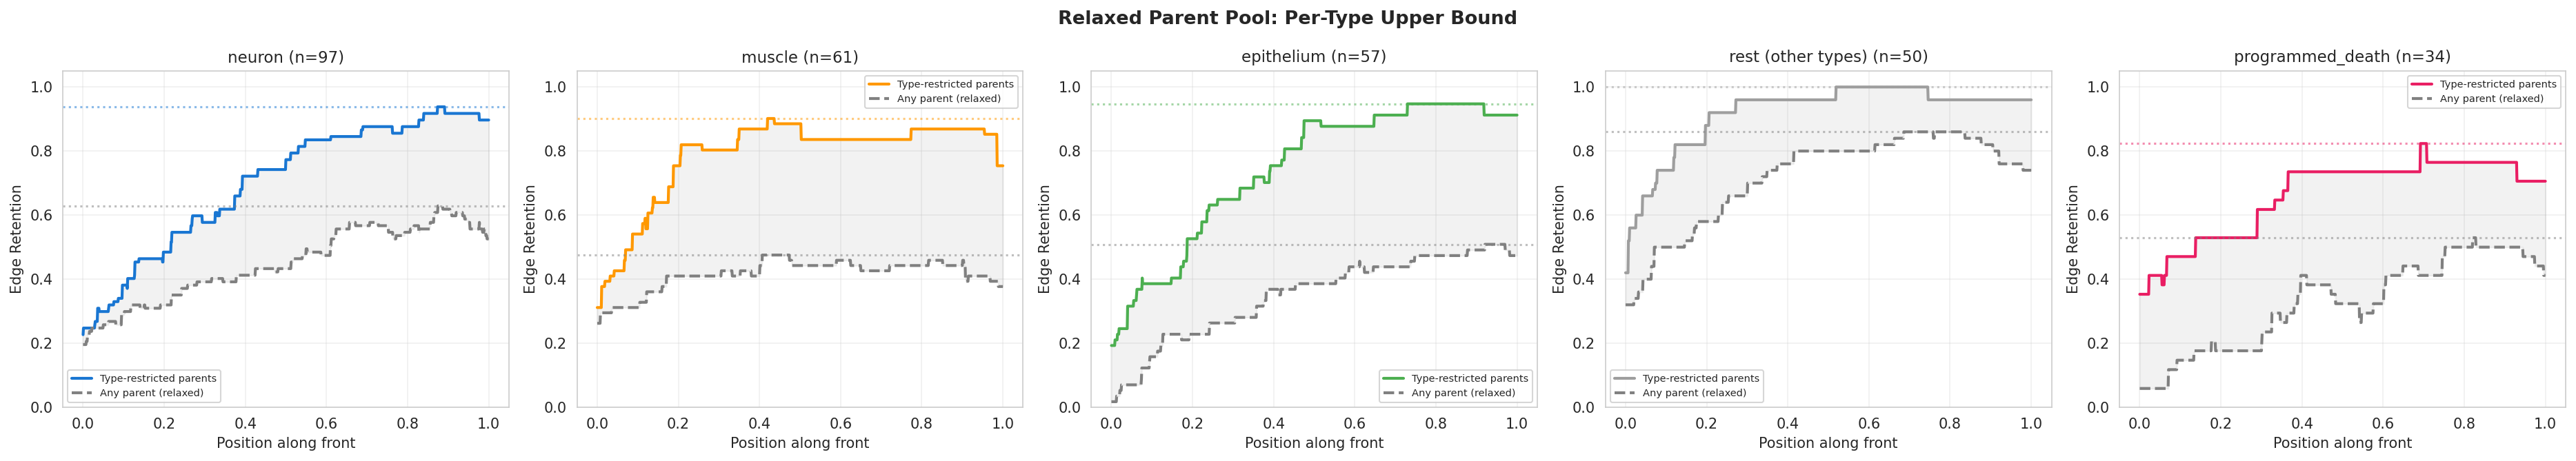

In [27]:
# ── Figure: Relaxed vs Restricted edge retention ──
fig, axes = plt.subplots(1, len(relaxed_results), figsize=(5*len(relaxed_results), 4.5))
if len(relaxed_results) == 1:
    axes = [axes]

for ax, (gname, rd) in zip(axes, relaxed_results.items()):
    xf = np.linspace(0, 1, 1001)
    color_restricted = ct_colors.get(gname, 'gray')
    color_relaxed = 'gray'

    ax.plot(xf, rd['restricted_edges'], color=color_restricted, lw=2, label='Type-restricted parents')
    ax.plot(xf, rd['relaxed_edges'], color=color_relaxed, lw=2, ls='--', label='Any parent (relaxed)')
    ax.axhline(y=rd['restricted_res']['max_er'], color=color_restricted, ls=':', alpha=0.5)
    ax.axhline(y=rd['relaxed_edges'].max(), color=color_relaxed, ls=':', alpha=0.5)
    ax.fill_between(xf, rd['restricted_edges'], rd['relaxed_edges'], alpha=0.1, color='gray')
    ax.set_title(f'{gname} (n={rd["n"]})', fontsize=11)
    ax.set_xlabel('Position along front'); ax.set_ylabel('Edge Retention')
    ax.set_ylim(0, 1.05); ax.legend(fontsize=7); ax.grid(True, alpha=0.3)

fig.suptitle('Relaxed Parent Pool: Per-Type Upper Bound', fontsize=13, fontweight='bold')
fig.tight_layout(); plt.show()


### 3c. Full-Tree Assignment Decomposed by Cell Type

Take the full-tree Pareto front assignment and compute per-type edge retention.
This shows which cell types' lineage edges are preserved vs. sacrificed in the
global optimum (where all 299 cells compete for parents simultaneously).

In [28]:
# ── Decompose full-tree Pareto front by cell type (grouped) ──
xm_full = xm_prot; em_full = em_prot; tp_full = tp_prot; tn_full = tn_prot

# Map terminal cells to merged types
ct_df_full = pd.read_csv('data/2023-06-29_entropy_cell_key_V2.csv')
lt_map = {}
for _, row in ct_df_full.iterrows():
    ln = row.get('wormweb.lineage',''); rt = row.get('wormweb.type','')
    if pd.notna(rt) and rt.strip():
        lt_map[ln] = MERGE_MAP.get(rt.strip(), rt.strip())

full_node_type = {}
for n in tn_full:
    full_node_type[n] = lt_map.get(n, 'programmed_death')

# Group: neuron, muscle, epithelium, programmed_death, rest
MAJOR_TYPES = {'neuron', 'muscle', 'epithelium', 'programmed_death'}
full_type_groups = defaultdict(list)
for i, (node, parent) in enumerate(zip(tn_full, tp_full)):
    ct = full_node_type.get(node, 'programmed_death')
    group = ct if ct in MAJOR_TYPES else 'rest (other types)'
    full_type_groups[group].append(i)

print("Group sizes:")
for ct in sorted(full_type_groups, key=lambda c: -len(full_type_groups[c])):
    print(f"  {ct:20s}: {len(full_type_groups[ct]):3d}")

# Normalize cost matrices
xm_n = (xm_full - xm_full.min()) / (xm_full.max() - xm_full.min())
em_n = (em_full - em_full.min()) / (em_full.max() - em_full.min())

# Find key alpha points
best_er, best_alpha = 0, 0
for i in range(1001):
    a = i/1000; ri, ci = linear_sum_assignment(a*xm_n + (1-a)*em_n)
    er = sum(1 for r,c in zip(ri,ci) if tp_full[r]==tp_full[c]) / len(tp_full)
    if er > best_er: best_er, best_alpha = er, i
key_alphas = {'Expr opt (a=0)': 0, 'Max ER': best_alpha, 'Spatial opt (a=1)': 1000}

decomp_results = {}
for label, alpha_idx in key_alphas.items():
    a = alpha_idx / 1000
    ri, ci = linear_sum_assignment(a * xm_n + (1 - a) * em_n)
    type_er = {}
    for ct, indices in full_type_groups.items():
        edges = sum(1 for idx in indices if tp_full[ri[idx]] == tp_full[ci[idx]])
        type_er[ct] = edges / len(indices) if len(indices) > 0 else 0
    decomp_results[label] = {'alpha_idx': alpha_idx, 'type_er': type_er, 'row_ind': ri, 'col_ind': ci}

# Table
overall_er = {k: sum(1 for r,c in zip(v['row_ind'],v['col_ind']) if tp_full[r]==tp_full[c])/len(tp_full)
              for k,v in decomp_results.items()}
print(f"\nOverall ER: Expr opt={overall_er['Expr opt (a=0)']:.3f}, Max ER={overall_er['Max ER']:.3f}, Spatial opt={overall_er['Spatial opt (a=1)']:.3f}")
print()

decomp_rows = []
for ct in sorted(full_type_groups, key=lambda c: -len(full_type_groups[c])):
    n = len(full_type_groups[ct])
    decomp_rows.append({
        'Cell Type': ct, 'N': n,
        'Expr opt ER': round(decomp_results['Expr opt (a=0)']['type_er'][ct], 3),
        'Max ER point': round(decomp_results['Max ER']['type_er'][ct], 3),
        'Spatial opt ER': round(decomp_results['Spatial opt (a=1)']['type_er'][ct], 3),
    })
decomp_df = pd.DataFrame(decomp_rows).set_index('Cell Type')
decomp_df


Group sizes:
  neuron              :  97
  muscle              :  61
  epithelium          :  57
  rest (other types)  :  50
  programmed_death    :  34



Overall ER: Expr opt=0.204, Max ER=0.819, Spatial opt=0.599



,N,Expr opt ER,Max ER point,Spatial opt ER
Cell Type,,,,
neuron,97,0.227,0.814,0.660
muscle,61,0.311,0.803,0.443
epithelium,57,0.105,0.807,0.667
rest (other types),50,0.240,0.920,0.660
programmed_death,34,0.059,0.735,0.500


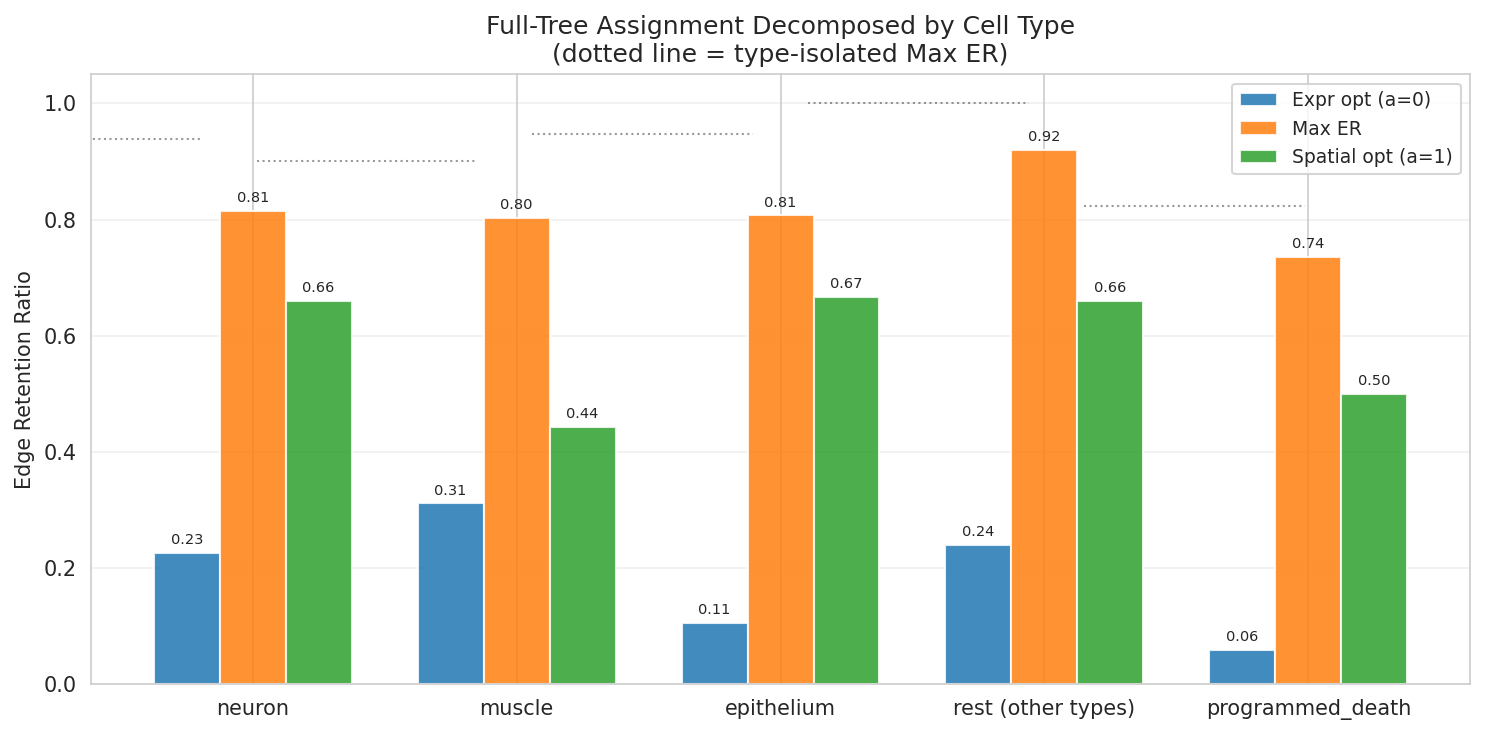

In [29]:
# ── Figure: Per-type edge retention in global assignment (grouped) ──
fig, ax = plt.subplots(figsize=(10, 5))

types_ordered = sorted(full_type_groups, key=lambda c: -len(full_type_groups[c]))
x = np.arange(len(types_ordered))
w = 0.25

for i, (label, alpha_idx) in enumerate(key_alphas.items()):
    ers = [decomp_results[label]['type_er'][ct] for ct in types_ordered]
    bars = ax.bar(x + i*w - w, ers, w, label=label, alpha=0.85)
    for bar, er in zip(bars, ers):
        if er > 0.05:
            ax.text(bar.get_x() + bar.get_width()/2., bar.get_height() + 0.01,
                    f'{er:.2f}', ha='center', va='bottom', fontsize=7)

# Reference: per-type isolated Max ER (dotted lines)
for i, ct in enumerate(types_ordered):
    if ct in ct_results:
        ref_er = ct_results[ct]['res']['max_er']
    elif ct == 'rest (other types)':
        ref_er = ct_results['rest (other types)']['res']['max_er']
    else:
        ref_er = None
    if ref_er is not None:
        ax.axhline(y=ref_er, xmin=(i-0.4)/len(types_ordered),
                   xmax=(i+0.4)/len(types_ordered), color='black', ls=':', alpha=0.4, lw=1)

ax.set_xticks(x); ax.set_xticklabels(types_ordered, fontsize=10)
ax.set_ylabel('Edge Retention Ratio'); ax.set_ylim(0, 1.05)
ax.set_title('Full-Tree Assignment Decomposed by Cell Type\n(dotted line = type-isolated Max ER)', fontsize=12)
ax.legend(fontsize=9); ax.grid(True, alpha=0.3, axis='y')
fig.tight_layout(); plt.show()


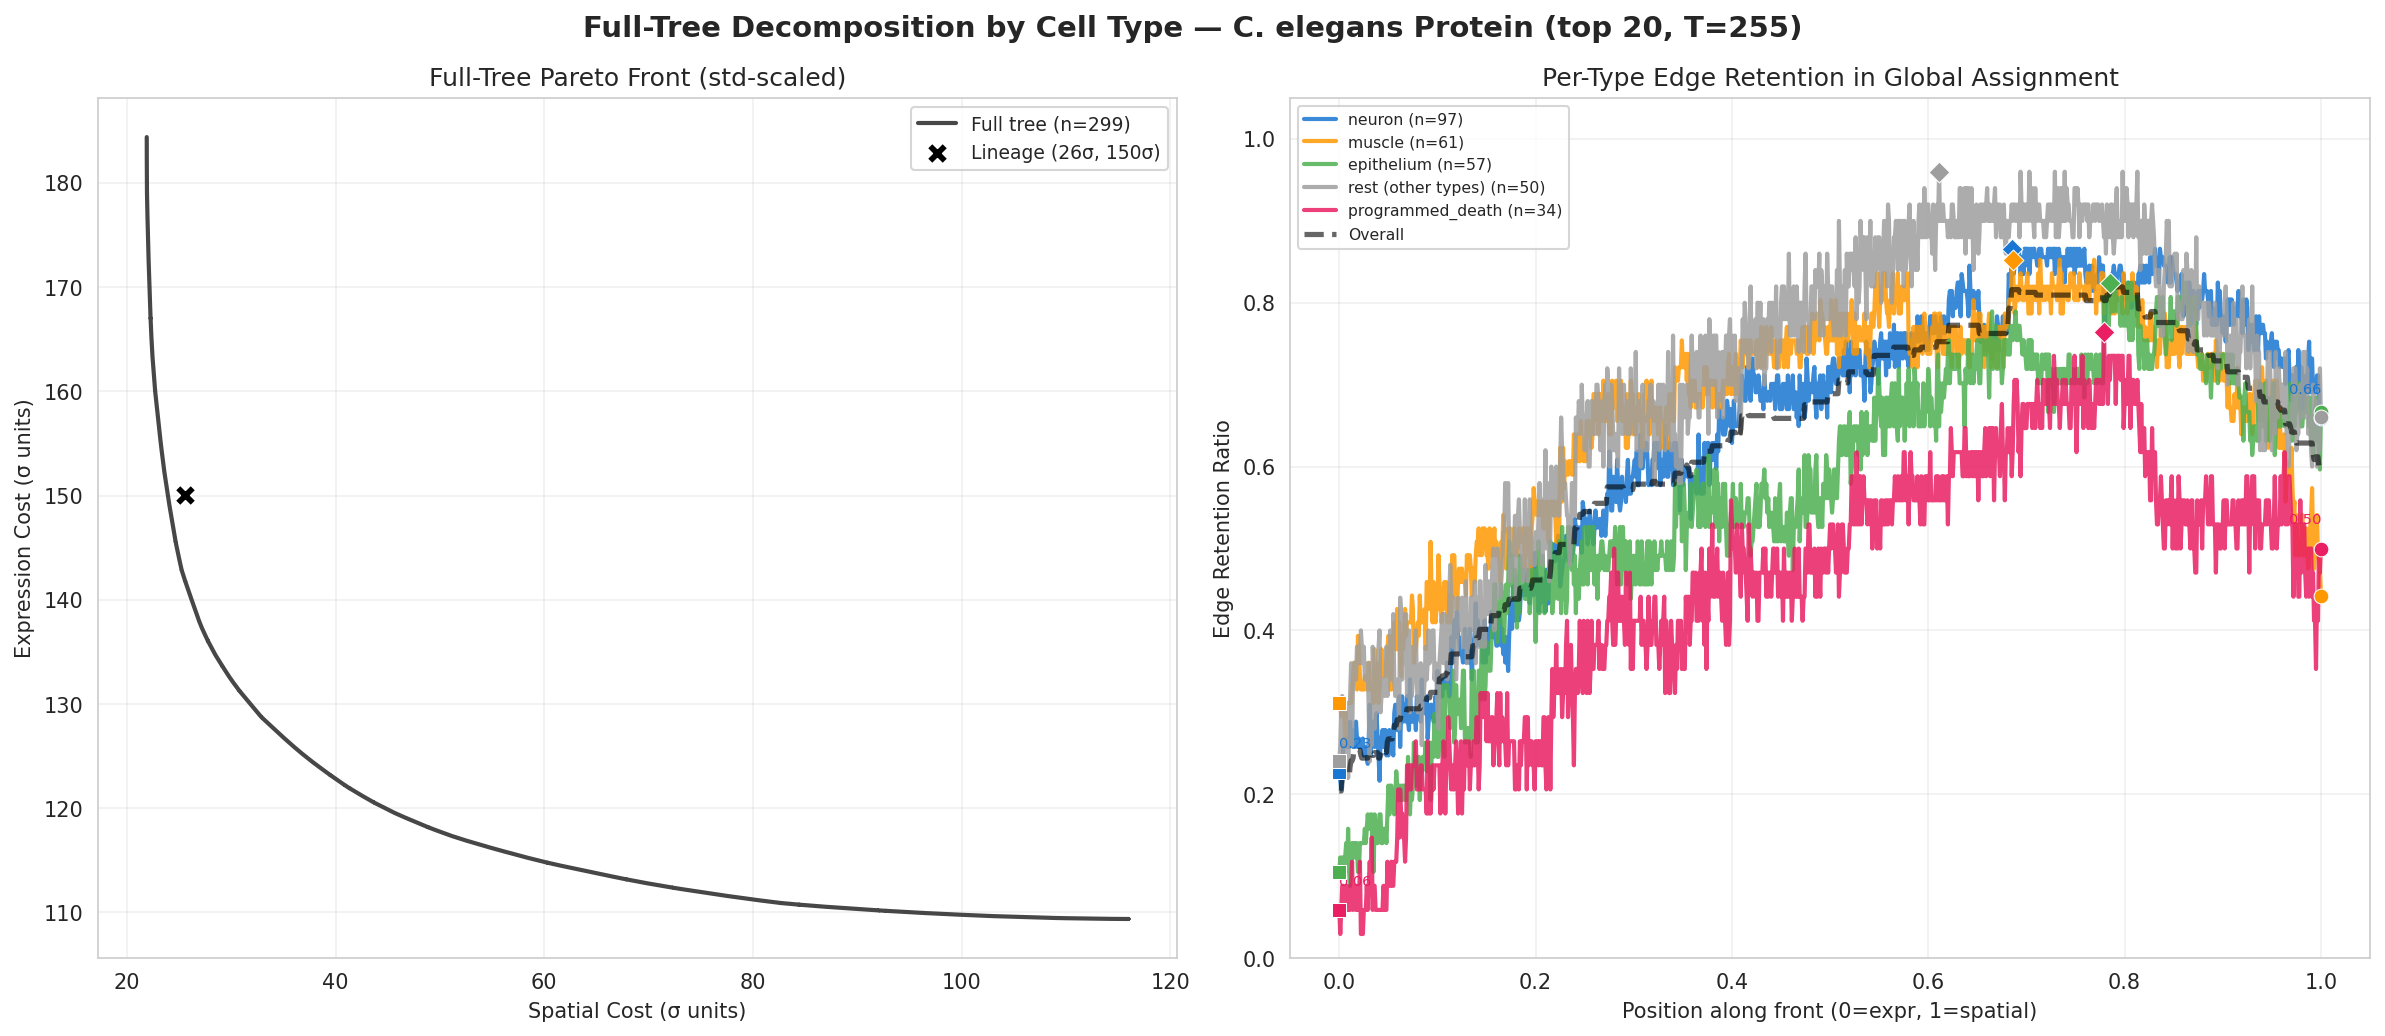

In [30]:
# ── Figure: Full-tree Pareto front + per-type edge retention curves (std-scaled) ──

type_list = sorted(full_type_groups, key=lambda c: -len(full_type_groups[c]))
type_colors = {'neuron': '#1976D2', 'muscle': '#FF9800', 'epithelium': '#4CAF50',
               'rest (other types)': '#9E9E9E', 'programmed_death': '#E91E63'}

# Compute std-based Pareto front for the full tree
xyz_arr, exp_arr, __, ___ = compute_std_scaled_pareto(xm_full, em_full, tp_full, prot_rs)

# Lineage position in std units
lx = xm_full.diagonal().sum() / prot_rs['xyz_std']
le = em_full.diagonal().sum() / prot_rs['exp_std']

# Compute per-type edge retention at each alpha
per_type_edges = {ct: [] for ct in type_list}
for i in range(1001):
    a = i / 1000
    ri, ci = linear_sum_assignment(a * xm_n + (1 - a) * em_n)
    for ct, indices in full_type_groups.items():
        edges = sum(1 for idx in indices if tp_full[ri[idx]] == tp_full[ci[idx]])
        per_type_edges[ct].append(edges / len(indices))

fig, (ax_l, ax_r) = plt.subplots(1, 2, figsize=(16, 7))
x_front = np.linspace(0, 1, 1001)

# ── LEFT: Full-tree Pareto front (std-scaled) ──
ax_l.plot(xyz_arr, exp_arr, color='#333333', lw=2, alpha=0.9, label=f'Full tree (n={len(tn_full)})')
ax_l.scatter(lx, le, color='black', marker='X', s=100, edgecolors='white', lw=0.8, zorder=10,
           label=f'Lineage ({lx:.0f}σ, {le:.0f}σ)')
ax_l.set_xlabel('Spatial Cost (σ units)')
ax_l.set_ylabel('Expression Cost (σ units)')
ax_l.set_title('Full-Tree Pareto Front (std-scaled)', fontsize=12)
ax_l.legend(fontsize=9, loc='upper right')
ax_l.grid(True, alpha=0.3)

# ── RIGHT: Per-type edge retention along the full-tree front ──
for ct in type_list:
    color = type_colors.get(ct, 'gray')
    edges = np.array(per_type_edges[ct])
    ax_r.plot(x_front, edges, color=color, lw=2, alpha=0.85, label=f'{ct} (n={len(full_type_groups[ct])})')
    ax_r.scatter(0, edges[0], color=color, marker='s', s=50, zorder=8, edgecolors='white', lw=0.5)
    ax_r.scatter(1, edges[-1], color=color, marker='o', s=50, zorder=8, edgecolors='white', lw=0.5)
    max_idx = np.argmax(edges)
    ax_r.scatter(x_front[max_idx], edges[max_idx], color=color, marker='D', s=50, zorder=8, edgecolors='white', lw=0.5)
    if ct in ['neuron', 'programmed_death']:
        ax_r.annotate(f'{edges[0]:.2f}', (0, edges[0]+0.03), color=color, fontsize=7, ha='left')
        ax_r.annotate(f'{edges[-1]:.2f}', (1, edges[-1]+0.03), color=color, fontsize=7, ha='right')

overall_edges = []
for i in range(1001):
    a = i/1000
    ri, ci = linear_sum_assignment(a*xm_n + (1-a)*em_n)
    overall_edges.append(sum(1 for r,c in zip(ri,ci) if tp_full[r]==tp_full[c]) / len(tp_full))
ax_r.plot(x_front, overall_edges, color='black', lw=2.5, ls='--', alpha=0.6, label='Overall')

ax_r.set_xlabel('Position along front (0=expr, 1=spatial)')
ax_r.set_ylabel('Edge Retention Ratio')
ax_r.set_title('Per-Type Edge Retention in Global Assignment', fontsize=12)
ax_r.set_ylim(0, 1.05)
ax_r.grid(True, alpha=0.3)
ax_r.legend(fontsize=7.5, loc='best')

fig.suptitle('Full-Tree Decomposition by Cell Type — C. elegans Protein (top 20, T=255)',
             fontsize=14, fontweight='bold')
fig.tight_layout()
plt.show()


---
## Appendix: C. briggsae Tracking Config

Final selected configuration after comparison: **`CD140715HLH1cbp1.csv` with T≤155 cutoff** (69 terminal cells with RNA data).

This embryo + early cutoff gives the best spatial-expression coupling among tested options
(Max ER=0.754, Closest Dist=0.245), comparable to C. elegans at T≤230.


---
## 4. Grand Summary

In [31]:
# ── All results in one combined table ──
all_rows = []

# Full tree
all_rows.append({'Experiment': 'Full — C.elegans Protein (T=230)', 'Group': 'Full tree', 'N': len(tn_prot_early),
    'Expr Opt ER': res_prot_xs['expr_opt_er'], 'Max ER': res_prot_xs['max_er'], 'Spatial Opt ER': res_prot_xs['spatial_opt_er']})
all_rows.append({'Experiment': 'Full — C.elegans RNA (T=230)', 'Group': 'Full tree', 'N': len(tn_er_early),
    'Expr Opt ER': res_er_xs['expr_opt_er'], 'Max ER': res_er_xs['max_er'], 'Spatial Opt ER': res_er_xs['spatial_opt_er']})
all_rows.append({'Experiment': 'Full — C.briggsae RNA (T=155)', 'Group': 'Full tree', 'N': len(tn_cb),
    'Expr Opt ER': res_cb['expr_opt_er'], 'Max ER': res_cb['max_er'], 'Spatial Opt ER': res_cb['spatial_opt_er']})

# Subtrees
for label in ['AB', 'ABa', 'ABp', 'P1']:
    for exp_name, sub_dict in [('Subtree — C.elegans Protein', prot_sub), ('Subtree — C.elegans RNA', er_sub), ('Subtree — C.briggsae RNA', cb_sub)]:
        d = sub_dict[label]
        all_rows.append({'Experiment': exp_name, 'Group': label, 'N': len(d['tn']),
            'Expr Opt ER': d['res']['expr_opt_er'], 'Max ER': d['res']['max_er'], 'Spatial Opt ER': d['res']['spatial_opt_er']})

# Cell types
for gname in ct_results:
    d = ct_results[gname]
    all_rows.append({'Experiment': 'Cell Type — C.elegans Protein', 'Group': gname, 'N': len(d['tn']),
        'Expr Opt ER': d['res']['expr_opt_er'], 'Max ER': d['res']['max_er'], 'Spatial Opt ER': d['res']['spatial_opt_er']})

grand_df = pd.DataFrame(all_rows)
grand_df


,Experiment,Group,N,Expr Opt ER,Max ER,Spatial Opt ER
0,Full — C.elegans Protein (T=230),Full tree,90,0.211111,0.966667,0.844444
1,Full — C.elegans RNA (T=230),Full tree,70,0.100000,0.957143,0.885714
2,Full — C.briggsae RNA (T=155),Full tree,69,0.130435,0.753623,0.492754
3,Subtree — C.elegans Protein,AB,216,0.217593,0.837963,0.671296
4,Subtree — C.elegans RNA,AB,157,0.082803,0.936306,0.910828
5,Subtree — C.briggsae RNA,AB,37,0.243243,0.891892,0.837838
6,Subtree — C.elegans Protein,ABa,106,0.301887,0.886792,0.679245
7,Subtree — C.elegans RNA,ABa,73,0.136986,0.945205,0.945205
8,Subtree — C.briggsae RNA,ABa,21,0.380952,1.000000,0.904762
9,Subtree — C.elegans Protein,ABp,110,0.245455,0.881818,0.772727


### Key Takeaways

1. **Protein >> RNA for lineage signal.** Protein expression carries 2–3× more lineage
   information than RNA at every level (full tree and subtrees). The expression optimum
   edge retention for protein (0.20) far exceeds RNA (0.07) for C. elegans.

2. **Subdividing the tree amplifies signal.** Whether by lineage branch or cell type,
   smaller, more homogeneous groups show stronger spatial-expression coupling. Subtree
   Max ER reaches 0.88–0.95 vs 0.82 for the full tree.

3. **C. elegans RNA compensates via spatial info.** Despite weak expression-only signal
   (ER=0.07), the best trade-off achieves ER=0.81—matching protein's performance. The
   Pareto framework reveals that RNA data, though noisy alone, complements spatial
   proximity very effectively.

4. **C. briggsae shows weaker coupling.** Max ER peaks at 0.69 in the P1 subtree vs
   0.95 for C. elegans. This is partly due to lower-quality spatial data (spatial opt
   ER=0.31 vs 0.60–0.68) and partly genuine species differences.

5. **Cell types show near-perfect recapitulation.** Within a single cell type, the
   Pareto front achieves Max ER of 0.90–1.00. The "rest" group of minor types actually
   hits 100% edge retention—their diverse expression profiles make parent→child
   assignment unambiguous.

6. **Programmed death cells are molecularly distinct.** Apoptotic cells have the
   second-highest expression-only ER (0.35 in both full-tree protein and cell-type
   analyses), confirming that cell death involves strong, specific transcriptional
   programs.
